In [ ]:
# load the python modules we will use
import uproot # for data loading
import awkward as ak # for data manipulation
import hist # for histogram filling (and some plotting)

import matplotlib as mpl # for plotting
import matplotlib.pyplot as plt # common shorthand
from matplotlib.colors import PowerNorm
import matplotlib.cm as cm
import mplhep # style of plots
%matplotlib inline
mpl.style.use(mplhep.style.ROOT) # set the plot style
import numpy as np

print("\n".join(
    k for k in uproot.open("2electrons/experimental.v4/events11.root")["LDMX_Events"].keys()
    if "TriggerPadTracks" in k
))

f"TriggerPadTracks: track position map"

TriggerPadTracks_overlay
TriggerPadTracks_overlay/TriggerPadTracks_overlay.centroid_
TriggerPadTracks_overlay/TriggerPadTracks_overlay.centroid_x_
TriggerPadTracks_overlay/TriggerPadTracks_overlay.centroid_y_
TriggerPadTracks_overlay/TriggerPadTracks_overlay.centroid_z_
TriggerPadTracks_overlay/TriggerPadTracks_overlay.residual_
TriggerPadTracks_overlay/TriggerPadTracks_overlay.residual_x_
TriggerPadTracks_overlay/TriggerPadTracks_overlay.residual_y_
TriggerPadTracks_overlay/TriggerPadTracks_overlay.residual_z_
TriggerPadTracks_overlay/TriggerPadTracks_overlay.n_clusters_
TriggerPadTracks_overlay/TriggerPadTracks_overlay.constituents_
TriggerPadTracks_overlay/TriggerPadTracks_overlay.beam_efrac_
TriggerPadTracks_overlay/TriggerPadTracks_overlay.pe_
TriggerPadTracks_overlay/TriggerPadTracks_overlay.x_
TriggerPadTracks_overlay/TriggerPadTracks_overlay.y_
TriggerPadTracks_overlay/TriggerPadTracks_overlay.sx_
TriggerPadTracks_overlay/TriggerPadTracks_overlay.sy_
TriggerPadTracks_overlay/Tr

'TriggerPadTracks: track position map'

In [2]:
from pathlib import Path


def _read_arrays(tree, branches, max_events=None):
    out = tree.arrays(branches, library="np")
    return {k: v[:max_events] for k, v in out.items()} if max_events is not None else out


def _merge_dicts(dicts):
    if not dicts:
        return {}
    return {k: sum((list(d[k]) for d in dicts), []) for k in dicts[0]}


CONFIG = {
    "test": {
        "sim_pat": "TriggerPad{pad}SimHits_test/TriggerPad{pad}SimHits_test.",
        "clu_pat": "TriggerPad{pad}Clusters_test/TriggerPad{pad}Clusters_test.",
        "dig_pat": "trigScintDigisPad{pad}_test/trigScintDigisPad{pad}_test.",
        "dig_keys": ["energy_", "xpos_", "ypos_", "zpos_", "time_", "is_noise_", "pe_", "bar_id_"],
        "track_bases": {
            "ftr": "TriggerPadTracks_test/TriggerPadTracks_test.",
            "Xtr": "TriggerPadTracksX_test/TriggerPadTracksX_test.",
            "Ytr": "TriggerPadTracksY_test/TriggerPadTracksY_test.",
        },
        "track_keys": ["x_", "y_", "z_", "centroid_", "centroid_x_", "centroid_y_", "sx_", "sy_","residual_","residual_x_","residual_y_"],
    },
    "overlay": {
        "sim_pat": "TriggerPad{pad}SimHitsOverlay_overlay/TriggerPad{pad}SimHitsOverlay_overlay.",
        "clu_pat": "TriggerPad{pad}Clusters_overlay/TriggerPad{pad}Clusters_overlay.",
        "dig_pat": "trigScintDigisPad{pad}_overlay/trigScintDigisPad{pad}_overlay.",
        "dig_keys": ["energy_", "xpos_", "ypos_", "zpos_", "time_", "is_noise_", "pe_"],
        "track_bases": {
            "ftr": "TriggerPadTracks_overlay/TriggerPadTracks_overlay.",
            "Xtr": "TriggerPadTracksX_overlay/TriggerPadTracksX_overlay.",
            "Ytr": "TriggerPadTracksY_overlay/TriggerPadTracksY_overlay.",
        },
        "track_keys": ["x_", "y_", "z_", "centroid_", "centroid_x_", "centroid_y_", "sx_", "sy_","residual_","residual_x_","residual_y_"],
    },
}


def load_ts(filename="events.root", pads=(1, 2, 3), max_events=None, mode="test"):
    if mode not in CONFIG:
        raise ValueError("mode must be 'test' or 'overlay'")

    cfg = CONFIG[mode]
    sim_keys = ["edep_", "x_", "y_", "z_", "time_", "n_contribs_"]
    clu_keys = ["energy_", "pe_", "centroid_x_","centroid_", "centroid_y_", "centroid_z_", "time_", "n_hits_"]

    sim, clu, dig = {}, {}, {}

    with uproot.open(filename) as f:
        tree = f["LDMX_Events"]

        for pad in pads:
            sim[f"pad{pad}"] = _read_arrays(
                tree, [cfg["sim_pat"].format(pad=pad) + k for k in sim_keys], max_events
            )
            clu[f"pad{pad}"] = _read_arrays(
                tree, [cfg["clu_pat"].format(pad=pad) + k for k in clu_keys], max_events
            )
            dig[f"pad{pad}"] = _read_arrays(
                tree, [cfg["dig_pat"].format(pad=pad) + k for k in cfg["dig_keys"]], max_events
            )

        tracks = {
            name: _read_arrays(tree, [base + k for k in cfg["track_keys"]], max_events)
            for name, base in cfg["track_bases"].items()
        }

    return sim, clu, dig, tracks["ftr"], tracks["Xtr"], tracks["Ytr"]


def load_ts_folder(folder, pattern="*.root", pads=(1, 2, 3), max_events=None, mode="test"):
    files = sorted(Path(folder).glob(pattern))
    if not files:
        raise FileNotFoundError(f"No files matching {pattern} in {folder}")

    loaded = [load_ts(str(file), pads=pads, max_events=max_events, mode=mode) for file in files]
    all_sim, all_clu, all_dig, all_ftr, all_Xtr, all_Ytr = zip(*loaded)

    sim = {pad: _merge_dicts([d[pad] for d in all_sim]) for pad in all_sim[0]}
    clu = {pad: _merge_dicts([d[pad] for d in all_clu]) for pad in all_clu[0]}
    dig = {pad: _merge_dicts([d[pad] for d in all_dig]) for pad in all_dig[0]}

    return sim, clu, dig, _merge_dicts(all_ftr), _merge_dicts(all_Xtr), _merge_dicts(all_Ytr)

# sim, clu, dig, ftr, Xtr, Ytr = load_ts(
#     filename="data/test5.root",
# )
# sim_alt, clu_alt, dig_alt, ftr_alt, Xtr_alt, Ytr_alt = load_ts(
#     filename="data/eventsAlt1_1_changed.root",
# )

sim, clu, dig, ftr, Xtr, Ytr = load_ts_folder(
        "2electrons/baseline.vf",
    pattern="*.root",
    mode="overlay"
)

# sim_alt, clu_alt, dig_alt, ftr_alt, Xtr_alt, Ytr_alt = load_ts_folder(
#         "2electrons/alternative",
#     pattern="*.root",
#     mode="overlay"
# )
sim_alt, clu_alt, dig_alt, ftr_alt, Xtr_alt, Ytr_alt = load_ts_folder(
        "2electrons/alternative.vf2",
    pattern="*.root",
    mode="overlay"
)

sim_exp, clu_exp, dig_exp, ftr_exp, Xtr_exp, Ytr_exp = load_ts_folder(
        "2electrons/experimental.vf2",
    pattern="*.root",
    mode="overlay"
)

# sim_exp, clu_exp, dig_exp, ftr_exp, Xtr_exp, Ytr_exp = load_ts(
#         "2electrons/experimental/events8.root",
#         mode = "overlay"
# )



Alternative geometry before redution:  28920
Alternative geometry before redution, x_min:  -99999.0
Alternative geometry after redution 25730
Alternative geometry centroid:  28920
Experimental geometry before redution, lenght of values:  31804
Experimental geometry before redution, x_min:  -99999.0
Experimental geometry after redution 28192
Experimental geometry centroid:  31804
-39.75


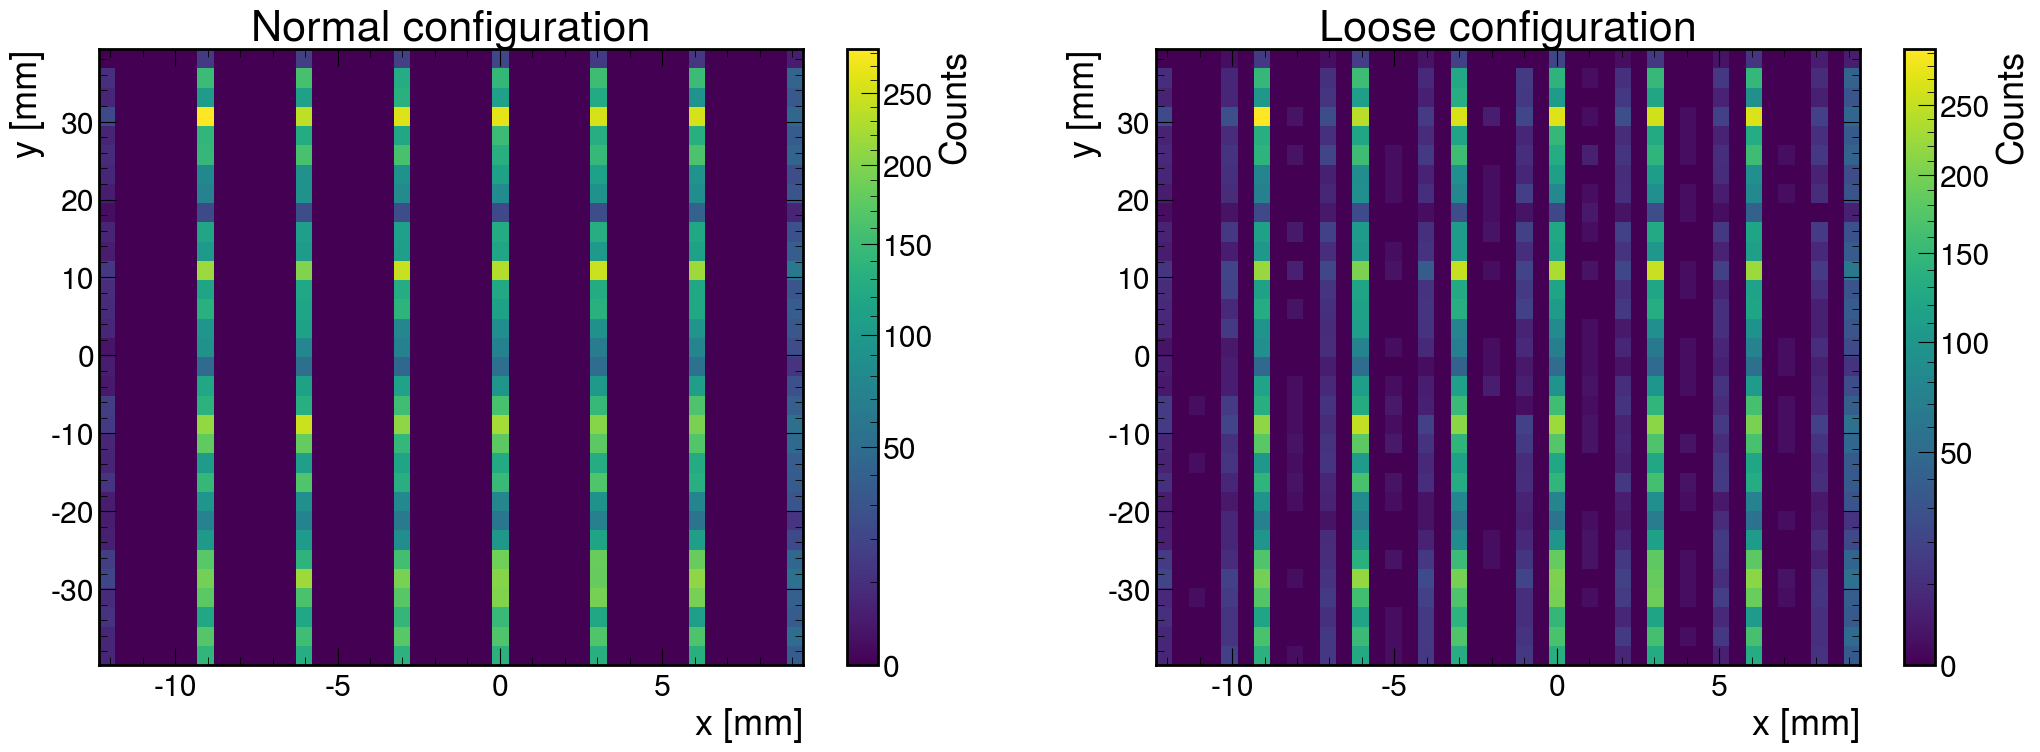

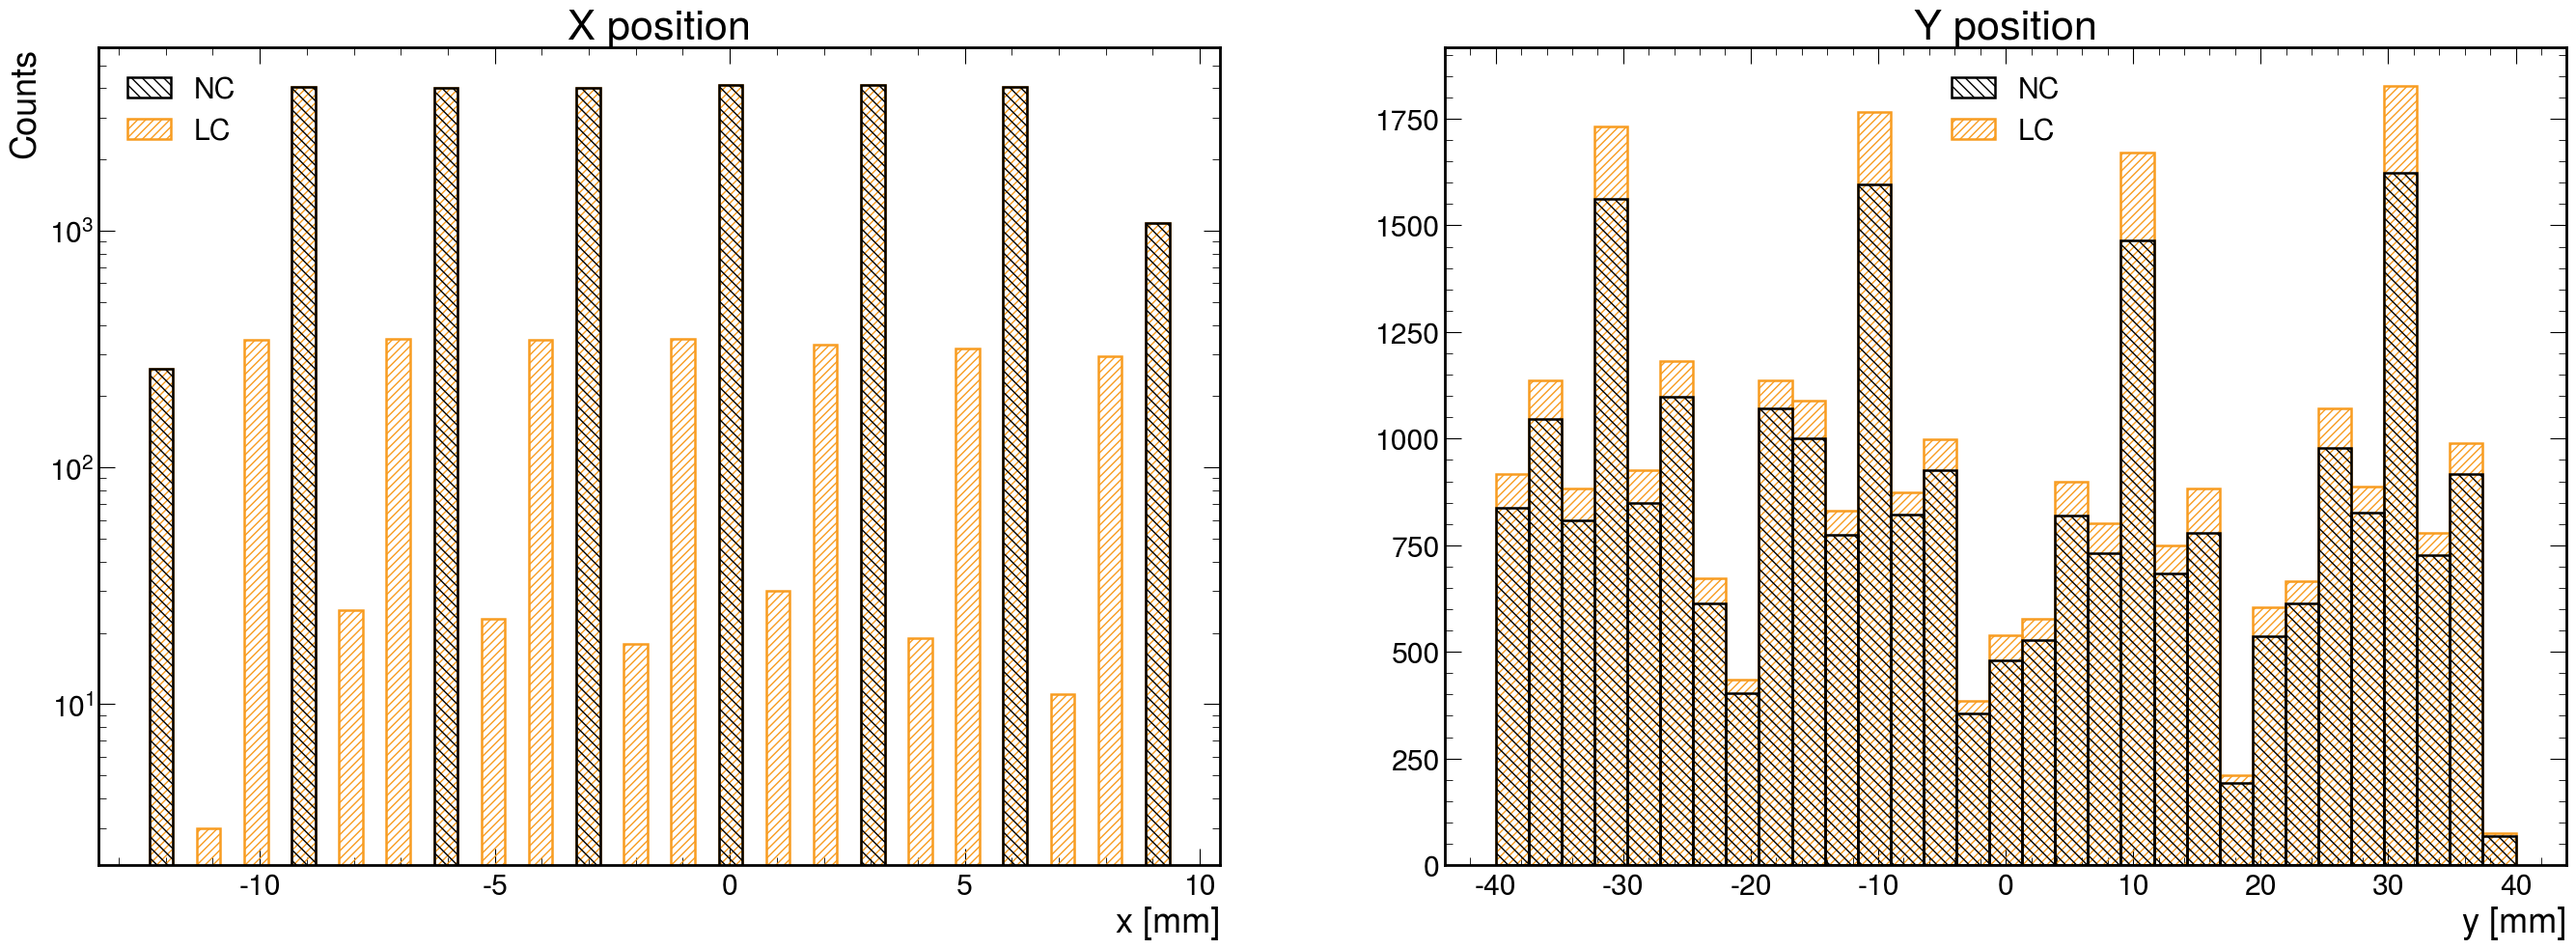

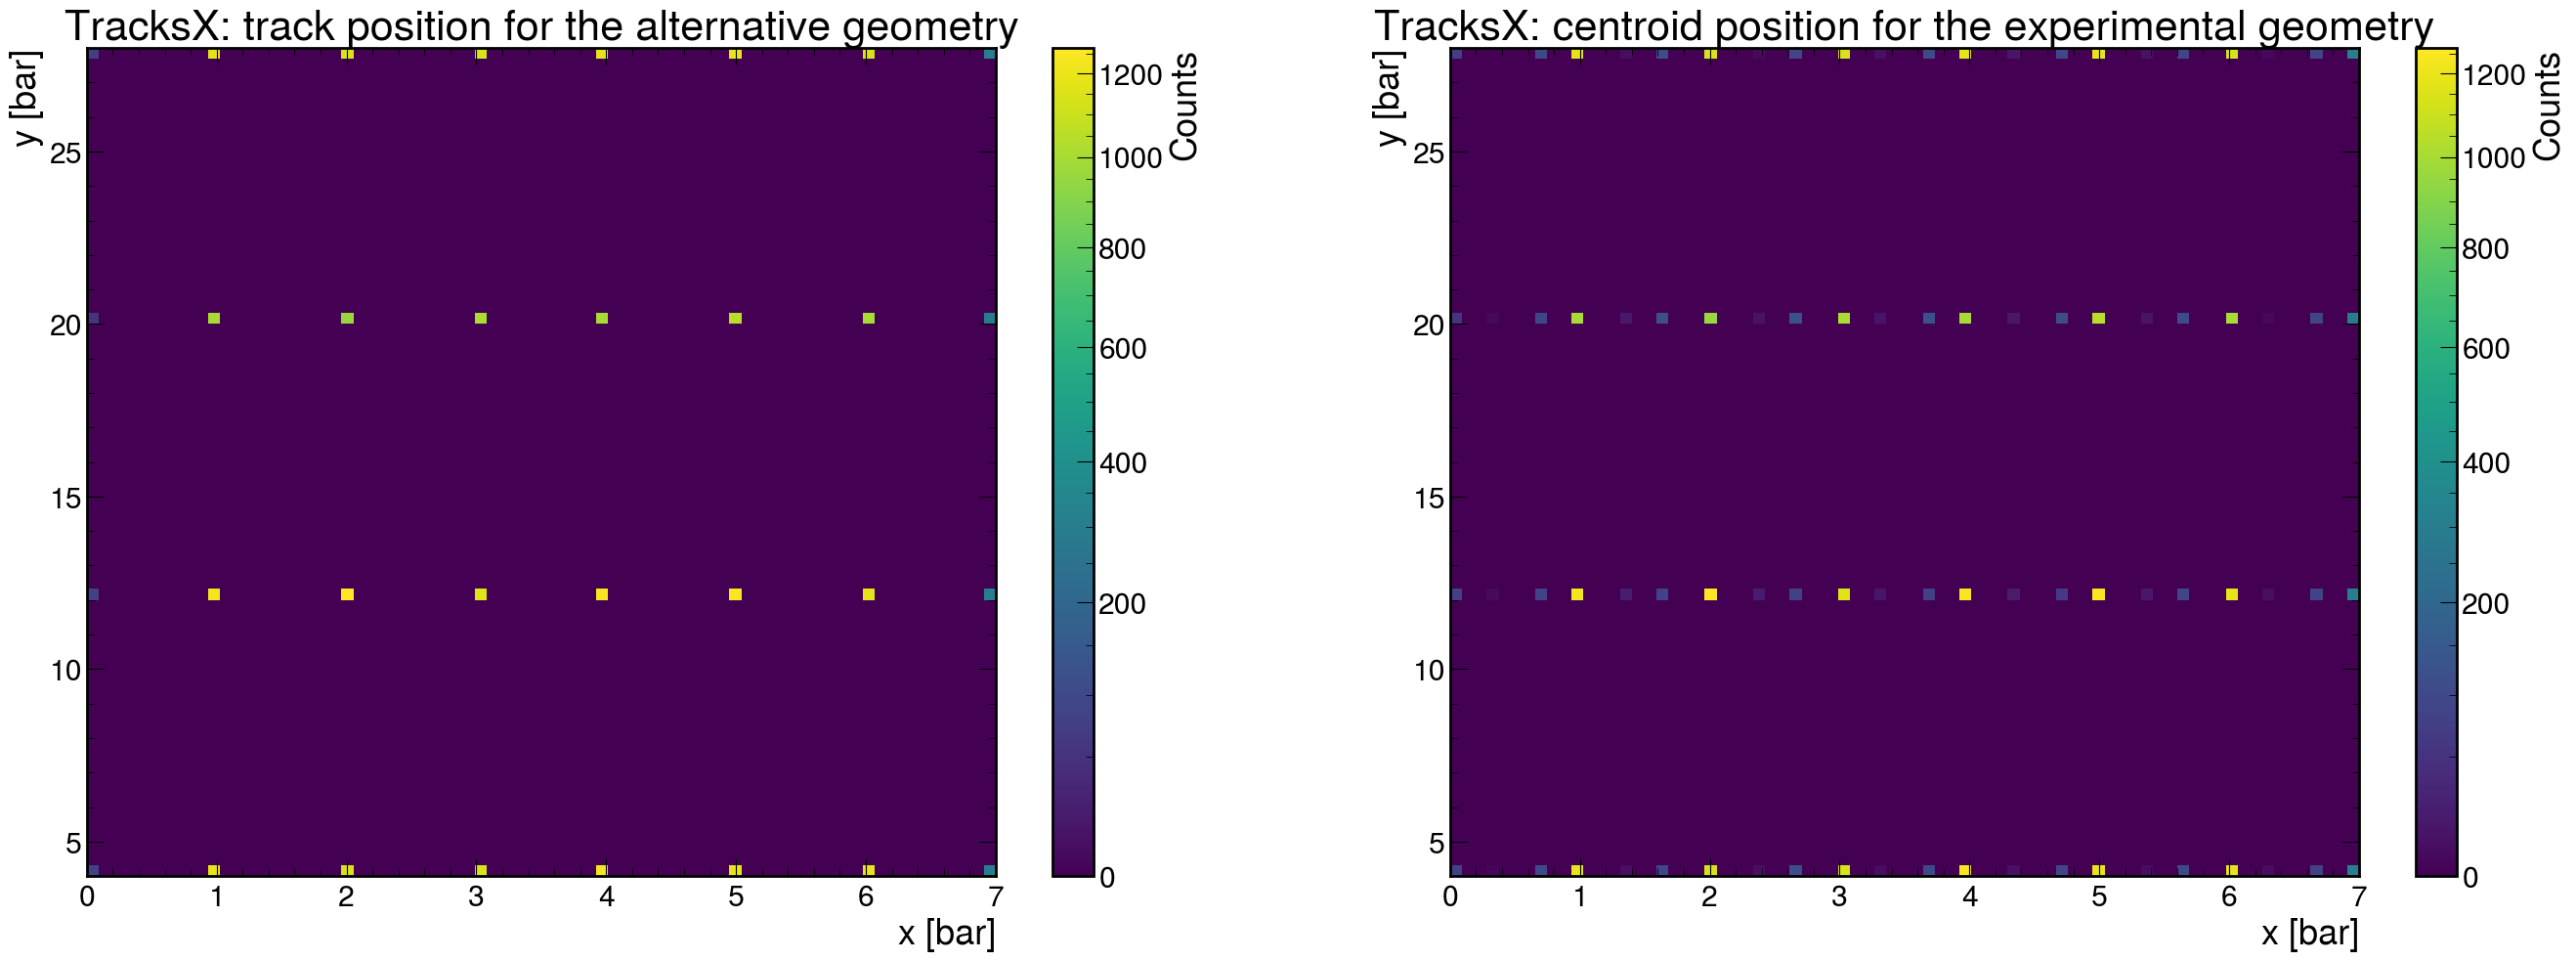

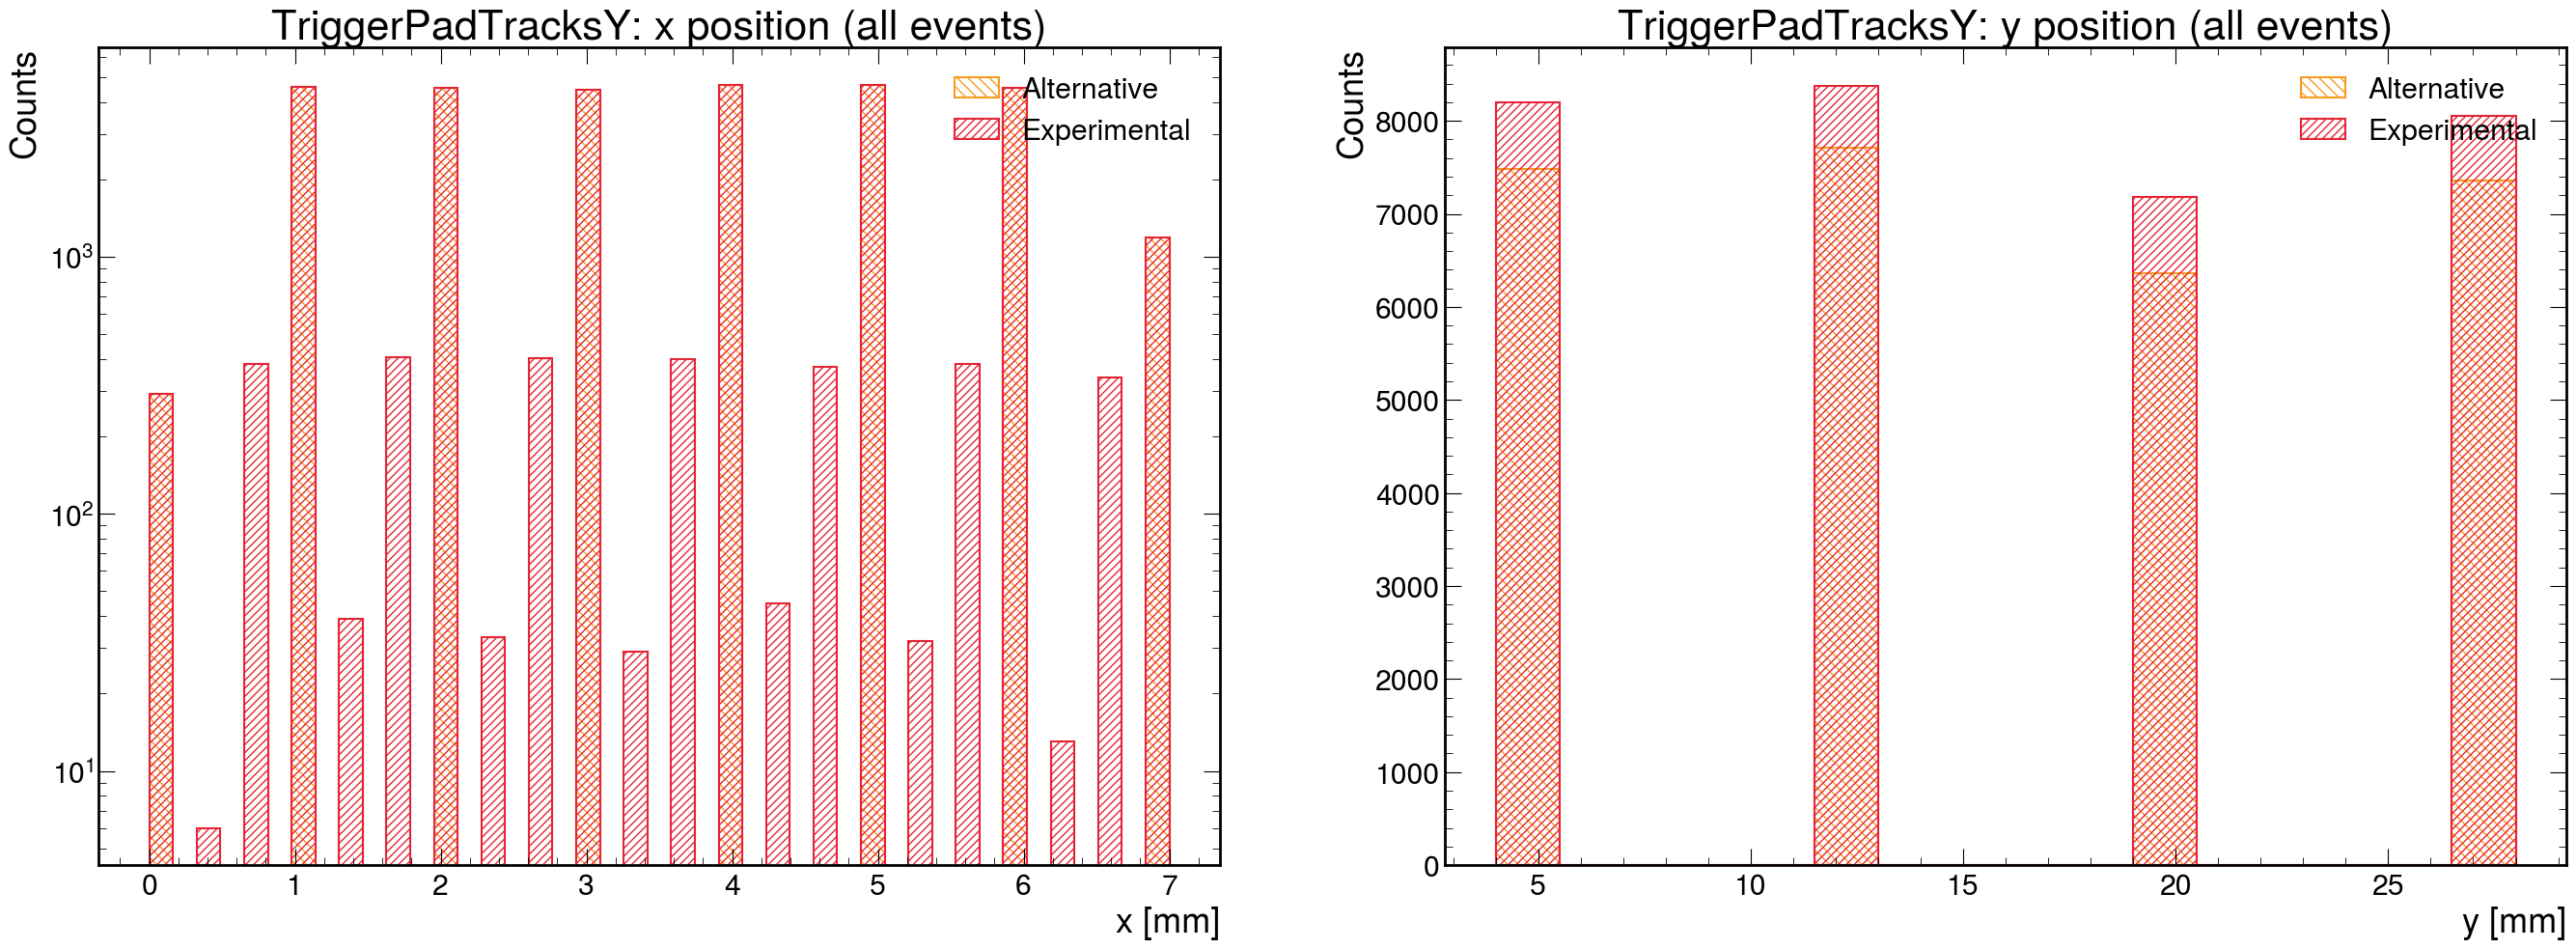

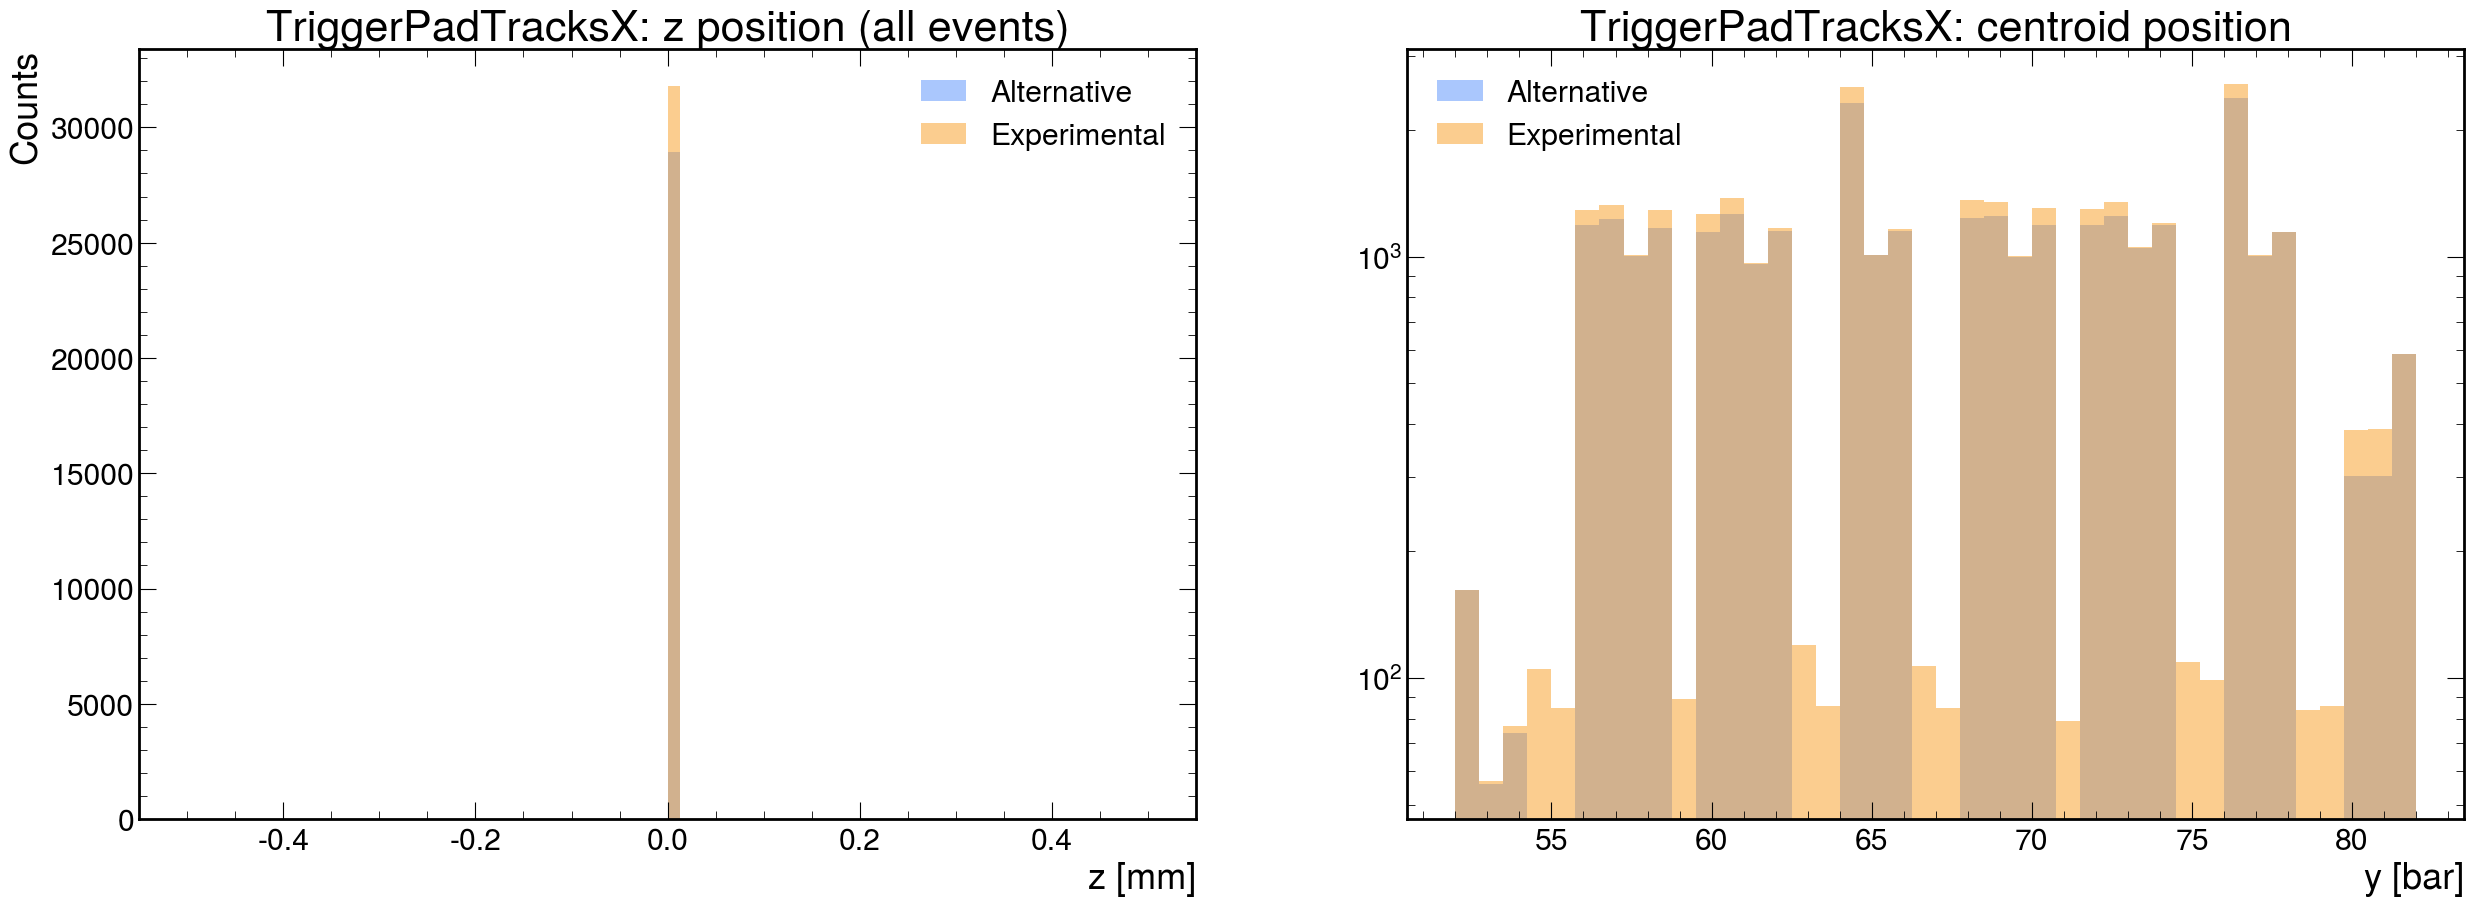

Alternative geometry before redution, sx:  28920
Alternative geometry before redution, sx_min:  -9999.0
Alternative geometry after redution, sx_ 25730
Experimental geometry before redution, lenght of values:  31804
Experimental geometry before redution, sx_min:  -9999.0
Experimental geometry after redution, lenght of values 25730


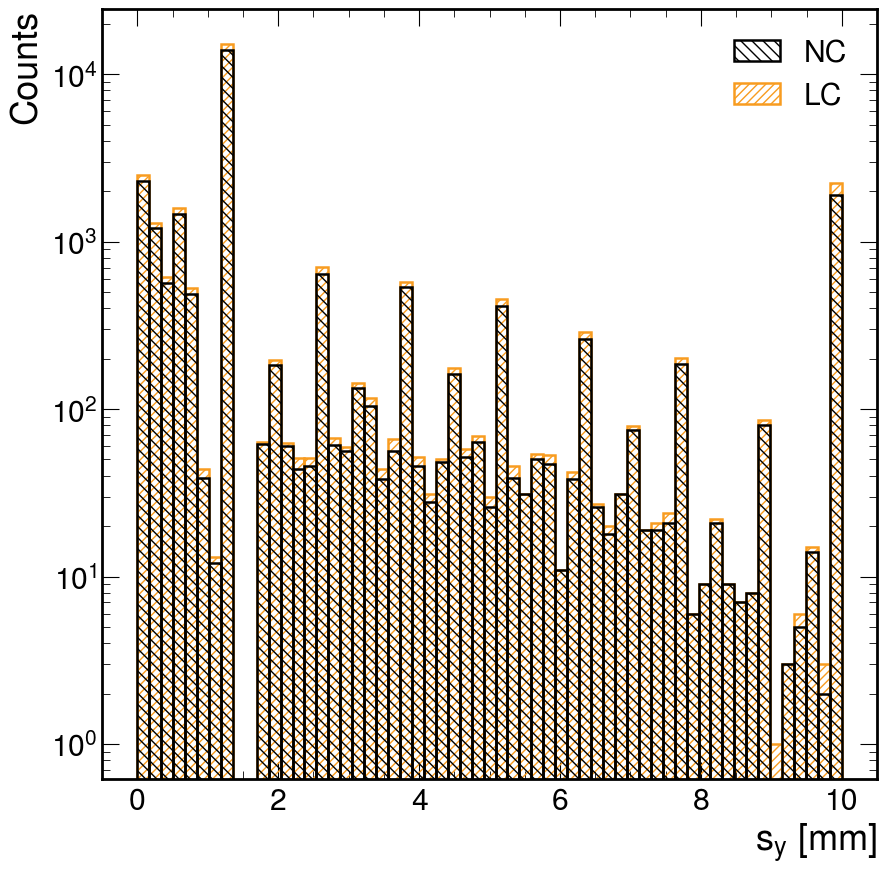

Alternative geometry: sx=(1.5499999523162842,1.5499999523162842) and sy=(0.0023065474815666676,10.02822208404541)
Experimental geometry: sx=(1.5499999523162842,1.5499999523162842) and sy=(0.0023065474815666676,10.02822208404541)


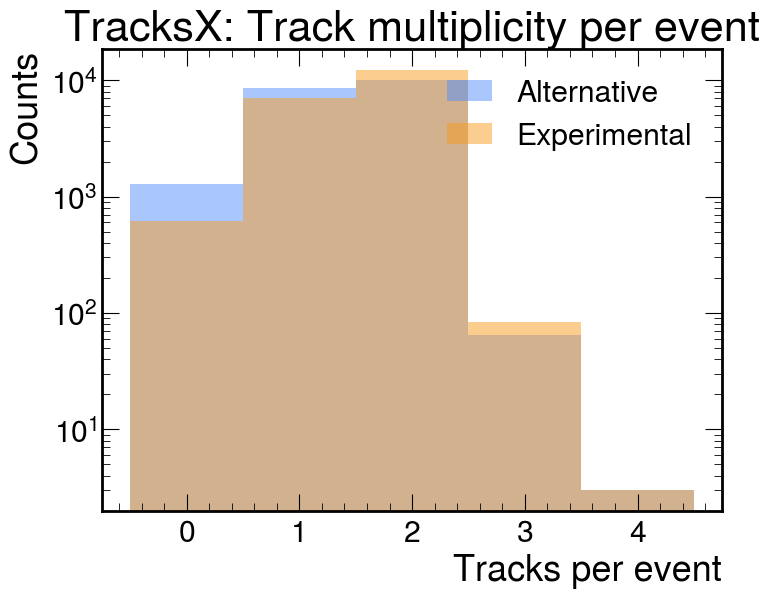

Number of 0-electron events:
- Alternative: 1273, 6.365 %
- Experimental: 622, 3.110 %
Number of 1-electron events:
- Alternative: 8605, 43.025 %
- Experimental: 7041, 35.205 %
Number of 2-electron events:
- Alternative: 10054, 50.270 %
- Experimental: 12251, 61.255 %
Number of 3-electron events:
- Alternative: 65, 0.325 %
- Experimental: 83, 0.415 %
Number of 4-electron events:
- Alternative: 3, 0.015 %
- Experimental: 3, 0.015 %
Without alone Xtracks
Number of 0-electron events:
- Alternative: 2358, 11.790 %
- Experimental: 1580, 7.900 %
Number of 1-electron events:
- Alternative: 9578, 47.890 %
- Experimental: 8675, 43.375 %
Number of 2-electron events:
- Alternative: 8041, 40.205 %
- Experimental: 9719, 48.595 %
Number of 3-electron events:
- Alternative: 22, 0.110 %
- Experimental: 25, 0.125 %
Number of 4-electron events:
- Alternative: 1, 0.005 %
- Experimental: 1, 0.005 %

TrueXtracks/Xtracks:
Alternative=20000  20000
Experimental=%



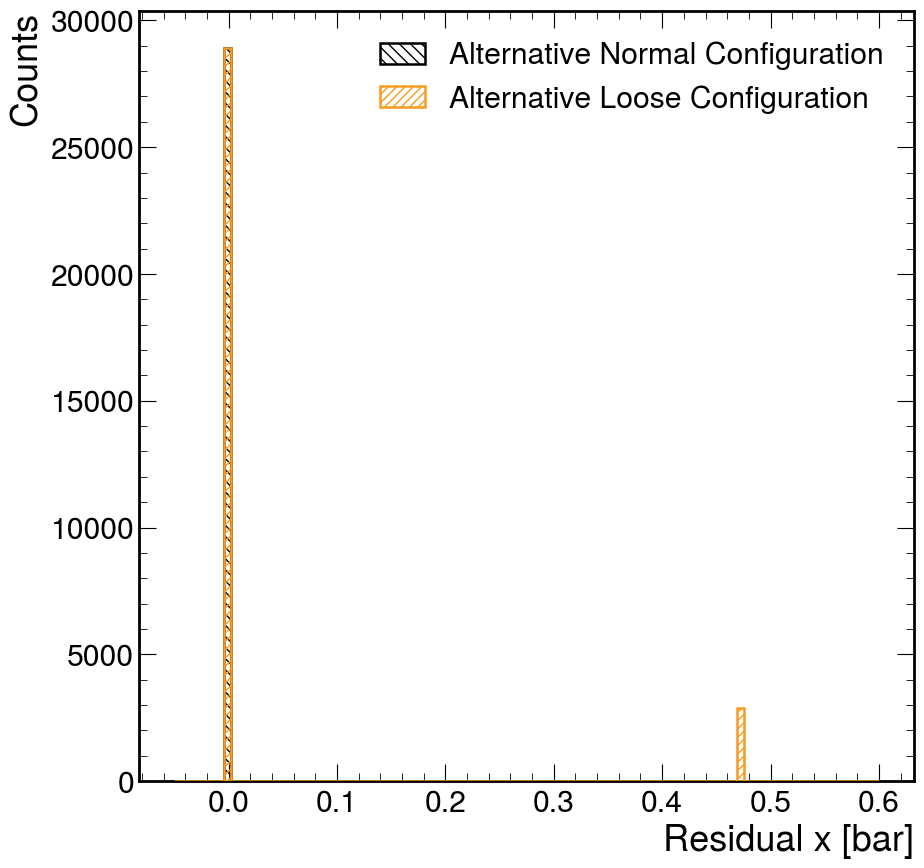

In [ ]:
def flatten_tracks(ftr_pad):
    base = f"TriggerPadTracksX_test/TriggerPadTracksX_test."
    # count tracks per event (this is your "w", but correct)
    count = np.array([len(ev) for ev in ftr_pad[base + "centroid_"]])
    x = np.concatenate(ftr_pad[base+"x_"])
    y = np.concatenate(ftr_pad[base+"y_"])
    z = np.concatenate(ftr_pad[base+"z_"])
    xc = np.concatenate(ftr_pad[base+"centroid_x_"])
    yc = np.concatenate(ftr_pad[base+"centroid_y_"])
    sx = np.concatenate(ftr_pad[base+"sx_"])
    sy = np.concatenate(ftr_pad[base+"sy_"])
    c = np.concatenate(ftr_pad[base+"centroid_"])
    
    # --- NEW: countTrue per event ---
    mask = (x >= -50)
    split_mask = np.split(mask, np.cumsum(count)[:-1])
    countTrue = np.array([np.sum(ev) for ev in split_mask])
    # --------------------------------

    return x, y, z, xc, yc, sx, sy, c, count

def flatten_tracks_(ftr_pad):
    base = f"TriggerPadTracksX_overlay/TriggerPadTracksX_overlay."
    # count tracks per event (this is your "w", but correct)
    count = np.array([len(ev) for ev in ftr_pad[base + "centroid_"]])
    x = np.concatenate(ftr_pad[base+"x_"])
    y = np.concatenate(ftr_pad[base+"y_"])
    z = np.concatenate(ftr_pad[base+"z_"])
    xc = np.concatenate(ftr_pad[base+"centroid_x_"])
    yc = np.concatenate(ftr_pad[base+"centroid_y_"])
    sx = np.concatenate(ftr_pad[base+"sx_"])
    sy = np.concatenate(ftr_pad[base+"sy_"])
    c = np.concatenate(ftr_pad[base+"centroid_"])
    r = np.concatenate(ftr_pad[base+"residual_"])
    rx = np.concatenate(ftr_pad[base+"residual_x_"])    
    # --- NEW: countTrue per event ---
    mask = (x >= -50)
    split_mask = np.split(mask, np.cumsum(count)[:-1])
    countTrue = np.array([np.sum(ev) for ev in split_mask])
    # --------------------------------

    return x, y, z, xc, yc, sx, sy, c, count,r,rx, countTrue

x, y, z, xc, yc, sx, sy, c, count,r,rx,countTrue = flatten_tracks_(Xtr)
x_, y_, z_, xc_, yc_, sx_, sy_, c_,count_,r_,rx_,countTrue_ = flatten_tracks_(Xtr_alt)
x_1, y_1, z_1, xc_1, yc_1, sx_1, sy_1, c_1,count_1,r_1,rx_1,countTrue_1 = flatten_tracks_(Xtr_exp)

print("Alternative geometry before redution: ",len(x_))

print("Alternative geometry before redution, x_min: ",min(x_))
# Update to eliminate "bad points"
mn = -50
y_ = y_[y_ >= mn]
x_ = x_[(x_ >=mn) ]
print("Alternative geometry after redution", len(x_))
print("Alternative geometry centroid: ",len(xc_))

print("Experimental geometry before redution, lenght of values: ",len(x_1))

print("Experimental geometry before redution, x_min: ",min(x_1))
# Update to eliminate "bad points"
mn = -50
y_1 = y_1[y_1 >= mn]
x_1 = x_1[(x_1 >=mn) ]
print("Experimental geometry after redution", len(x_1))
print("Experimental geometry centroid: ",len(xc_1))
print(min(y_1))

y_bins = np.linspace(-40, 40, 33)
yc_bins =np.linspace(0,32,33)
xc_bins=np.linspace(0,7,43)
x_bins=np.linspace(-13.85,10.85,43)

# 2D hit map (x-y position)
fig, axs = plt.subplots(1, 2, figsize=(25,8))
h0 = axs[0].hist2d(x_, y_, bins=(43,32),norm=PowerNorm(gamma=0.6))
axs[0].set_xlabel("x [mm]")
axs[0].set_ylabel("y [mm]")
axs[0].set_title(f"Normal configuration")

h1 = axs[1].hist2d(x_1, y_1, bins=(43,32),norm=PowerNorm(gamma=0.6))
axs[1].set_xlabel("x [mm]")
axs[1].set_ylabel("y [mm]")
axs[1].set_title(f"Loose configuration")

fig.colorbar(h0[3], ax=axs[0], label="Counts")
fig.colorbar(h1[3], ax=axs[1], label="Counts")
# fig.suptitle("TracksX: 2D Map for 1 electron/event")#, fontsize=18)
plt.savefig('plots/2elec/TracksX_position2D', dpi=300, bbox_inches="tight")
#plt.tight_layout() do not works with both
plt.show()

fig, axs = plt.subplots(1, 2, figsize=(33,11))


axs[0].hist(x_, bins=43, histtype='bar', facecolor='none', edgecolor='black',
            hatch='\\\\\\', linewidth=1.8, alpha=1, zorder=3,
            label='NC')

axs[0].hist(x_1, bins=43, histtype='bar', facecolor='none', edgecolor='C1',
            hatch='////', linewidth=1.8, alpha=1, zorder=2,
            label='LC')
axs[0].set_xlabel("x [mm]")
axs[0].set_ylabel("Counts")
axs[0].set_yscale('log')
axs[0].set_title(f"X position")
axs[0].legend(loc='upper left')#, bbox_to_anchor=(-0.03,1.03))

bins=np.linspace(-40,40,32)
axs[1].hist(y_, bins=bins, histtype='bar', facecolor='none', edgecolor='black',
            hatch='\\\\\\', linewidth=1.8, alpha=1, zorder=3, label='NC')
axs[1].hist(y_1, bins=bins, histtype='bar', facecolor='none', edgecolor='C1',
            hatch='////', linewidth=1.8, alpha=1, zorder=2, label='LC')
axs[1].set_xlabel("y [mm]")
axs[1].set_title(f"Y position")
axs[1].legend()
# fig.suptitle("TracksX: Position comparasion for 2 electrons/event")
plt.savefig('plots/2elec/TracksX_position1D', dpi=300, bbox_inches="tight")
#plt.tight_layout()
plt.show()

fig, axs = plt.subplots(1, 2, figsize=(33,11))
h0 = axs[0].hist2d(xc_, yc_, bins=75,norm=PowerNorm(gamma=0.6))
axs[0].set_xlabel("x [bar]")
axs[0].set_ylabel("y [bar]")
axs[0].set_title(f"TracksX: track position for the alternative geometry")

h1 = axs[1].hist2d(xc_1, yc_1, bins=75,norm=PowerNorm(gamma=0.6))
axs[1].set_xlabel("x [bar]")
axs[1].set_ylabel("y [bar]")
axs[1].set_title(f"TracksX: centroid position for the experimental geometry")

fig.colorbar(h0[3], ax=axs[0], label="Counts")
fig.colorbar(h1[3], ax=axs[1], label="Counts")   
#plt.tight_layout() do not works with both
plt.show()

fig, axs = plt.subplots(1, 2, figsize=(33,11))

axs[0].hist(xc_, bins=43, histtype='bar', facecolor='none',
            edgecolor='C1', hatch='\\\\\\', linewidth=1.5, label='Alternative')

axs[0].hist(xc_1, bins=43, histtype='bar', facecolor='none',
            edgecolor='C2', hatch='////', linewidth=1.5, label='Experimental')

axs[0].set_xlabel("x [mm]")
axs[0].set_ylabel("Counts")
axs[0].set_yscale('log')
axs[0].set_title("TriggerPadTracksY: x position (all events)")
axs[0].legend()

axs[1].hist(yc_, bins='auto', histtype='bar', facecolor='none',
            edgecolor='C1', hatch='\\\\\\', linewidth=1.5, label='Alternative')

axs[1].hist(yc_1, bins='auto', histtype='bar', facecolor='none',
            edgecolor='C2', hatch='////', linewidth=1.5, label='Experimental')

axs[1].set_xlabel("y [mm]")
axs[1].set_ylabel("Counts")
axs[1].set_title("TriggerPadTracksY: y position (all events)")
axs[1].legend()

plt.show()

fig, axs = plt.subplots(1, 2, figsize=(30,10))

axs[0].hist(z_, bins=80, alpha=0.5, label='Alternative')
axs[0].hist(z_1, bins=80, alpha=0.5, label='Experimental')
axs[0].set_xlabel("z [mm]")
axs[0].set_ylabel("Counts")
# axs[0].set_yscale('log')
axs[0].set_title(f"TriggerPadTracksX: z position (all events)")
axs[0].legend()

axs[1].hist(c_,  bins=40, alpha=0.5, label='Alternative')
axs[1].hist(c_1, bins=40, alpha=0.5, label='Experimental')
axs[1].set_xlabel("y [bar]")
axs[1].set_yscale('log')
axs[1].set_title(f"TriggerPadTracksX: centroid position")
axs[1].legend()

#plt.tight_layout()
plt.show()

print("Alternative geometry before redution, sx: ",len(sx_))

print("Alternative geometry before redution, sx_min: ",min(sx_))
# Update to eliminate "bad points"
mn = -50
sy_ = sy_[sy_ >= mn]
sx_ = sx_[(sx_ >=mn) ]
print("Alternative geometry after redution, sx_", len(sx_))

print("Experimental geometry before redution, lenght of values: ",len(sx_1))

print("Experimental geometry before redution, sx_min: ",min(sx_1))
# Update to eliminate "bad points"
mn = -50
sy_1 = sy_1[sy_1 >= mn]
sx_1 = sx_1[(sx_1 >=mn) ]
print("Experimental geometry after redution, lenght of values", len(sx_))

bins=np.linspace(0,10,60)
plt.figure()
plt.hist(sy_, bins=bins, histtype='bar', facecolor='none', edgecolor='black',
         hatch='\\\\\\', linewidth=1.8, alpha=1, zorder=3,
         label='NC')

plt.hist(sy_1, bins=bins, histtype='bar', facecolor='none', edgecolor='C1',
         hatch='////', linewidth=1.8, alpha=1, zorder=2,
         label='LC')
plt.xlabel("$s_y$ [mm]")
plt.ylabel("Counts")
plt.yscale('log')
# plt.title(f"TracksX: Uncertainty $s_y$ comparasion for 2 electrons/event")
plt.legend()
plt.savefig('plots/2elec/TracksX_uncertaintyY', dpi=300, bbox_inches="tight")

#plt.tight_layout()
plt.show()

# bins=np.linspace(0,10,60)
# # Z position distribution
# plt.figure()
# plt.hist(sy_, bins=bins, histtype='bar', facecolor='none',
#             edgecolor='C1', hatch='\\\\\\', linewidth=1.5,alpha=0.5, label='Alternative')
# plt.hist(sy_1, bins=bins, histtype='bar', facecolor='none',
#             edgecolor='C2', hatch='//////', linewidth=1.5,alpha=0.5,  label='Experimental')
# plt.xlabel("$s_y$ [mm]")
# plt.ylabel("Counts")
# plt.yscale('log')
# # plt.title(f"TracksX: Uncertainty $s_y$ comparasion for 2 electrons/event")
# plt.legend()
# plt.savefig('plots/2elec/TracksX_uncertaintyY', dpi=300, bbox_inches="tight")
# plt.show()

text= f"""Alternative geometry: sx=({min(sx_)},{max(sx_)}) and sy=({min(sy_)},{max(sy_)})
Experimental geometry: sx=({min(sx_1)},{max(sx_1)}) and sy=({min(sy_1)},{max(sy_1)})"""

print(text)

# Define bins centered on integers
max_count = int(max(count_.max(),count_1.max()))
bins = np.arange(-0.5, max_count + 1.5, 1)

# Plot
plt.figure(figsize=(8,6))

# plt.hist(count,  bins=bins, alpha=0.5, label='Baseline')#,density=True)
plt.hist(count_, bins=bins, alpha=0.5, label='Alternative')#,density=True)
plt.hist(count_1, bins=bins, alpha=0.5, label='Experimental')#,density=True)

plt.yscale('log')
plt.xlabel("Tracks per event")
plt.ylabel("Counts")
# plt.yscale('log')
plt.title("TracksX: Track multiplicity per event")
plt.legend()

plt.show()

text = f"""Number of 0-electron events:
- Alternative: {np.sum(count_ == 0)}, {np.sum(count_==0)*100/len(count_):.3f} %
- Experimental: {np.sum(count_1 == 0)}, {np.sum(count_1==0)*100/len(count_1):.3f} %
Number of 1-electron events:
- Alternative: {np.sum(count_ == 1)}, {np.sum(count_==1)*100/len(count_):.3f} %
- Experimental: {np.sum(count_1 == 1)}, {np.sum(count_1==1)*100/len(count_1):.3f} %
Number of 2-electron events:
- Alternative: {np.sum(count_ == 2)}, {np.sum(count_==2)*100/len(count_):.3f} %
- Experimental: {np.sum(count_1 == 2)}, {np.sum(count_1==2)*100/len(count_1):.3f} %
Number of 3-electron events:
- Alternative: {np.sum(count_ == 3)}, {np.sum(count_==3)*100/len(count_):.3f} %
- Experimental: {np.sum(count_1 == 3)}, {np.sum(count_1==3)*100/len(count_1):.3f} %
Number of 4-electron events:
- Alternative: {np.sum(count_ == 4)}, {np.sum(count_==4)*100/len(count_):.3f} %
- Experimental: {np.sum(count_1 == 4)}, {np.sum(count_1==4)*100/len(count_1):.3f} %
Without alone Xtracks
Number of 0-electron events:
- Alternative: {np.sum(countTrue_ == 0)}, {np.sum(countTrue_==0)*100/len(countTrue_):.3f} %
- Experimental: {np.sum(countTrue_1 == 0)}, {np.sum(countTrue_1==0)*100/len(countTrue_1):.3f} %
Number of 1-electron events:
- Alternative: {np.sum(countTrue_ == 1)}, {np.sum(countTrue_==1)*100/len(countTrue_):.3f} %
- Experimental: {np.sum(countTrue_1 == 1)}, {np.sum(countTrue_1==1)*100/len(countTrue_1):.3f} %
Number of 2-electron events:
- Alternative: {np.sum(countTrue_ == 2)}, {np.sum(countTrue_==2)*100/len(countTrue_):.3f} %
- Experimental: {np.sum(countTrue_1 == 2)}, {np.sum(countTrue_1==2)*100/len(countTrue_1):.3f} %
Number of 3-electron events:
- Alternative: {np.sum(countTrue_ == 3)}, {np.sum(countTrue_==3)*100/len(countTrue_):.3f} %
- Experimental: {np.sum(countTrue_1 == 3)}, {np.sum(countTrue_1==3)*100/len(countTrue_1):.3f} %
Number of 4-electron events:
- Alternative: {np.sum(countTrue_ == 4)}, {np.sum(countTrue_==4)*100/len(countTrue_):.3f} %
- Experimental: {np.sum(countTrue_1 == 4)}, {np.sum(countTrue_1==4)*100/len(countTrue_1):.3f} %

TrueXtracks/Xtracks:
Alternative={len(countTrue_)}  {len(count_)}
Experimental=%
"""
print(text)


# Residual position distribution
plt.figure()
bins=np.linspace(-0.05,0.6,100)
plt.hist(rx_, bins=bins, histtype='bar', facecolor='none', edgecolor='black',
            hatch='\\\\\\', linewidth=1.8, alpha=1, zorder=3, 
         label='Alternative Normal Configuration')
plt.hist(rx_1, bins=bins, histtype='bar', facecolor='none', edgecolor='C1',
            hatch='////', linewidth=1.8, alpha=1, zorder=3, 
         label='Alternative Loose Configuration')
plt.xlabel("Residual x [bar]")
plt.ylabel("Counts")
plt.legend()
plt.savefig('plots/2elec/TracksX_rx', dpi=300, bbox_inches="tight")
plt.show()



In [44]:
x_, y_, z_, xc_, yc_, sx_, sy_, c_, count_, r_, rx_, countTrue_ = flatten_tracks_(Xtr_alt)
x_1, y_1, z_1, xc_1, yc_1, sx_1, sy_1, c_1, count_1, r_1, rx_1, countTrue_1 = flatten_tracks_(Xtr_exp)

event_id_ = np.concatenate([np.full(n, i) for i, n in enumerate(count_)])
event_id_1 = np.concatenate([np.full(n, i) for i, n in enumerate(count_1)])

# Round first
sy_round_ = np.round(sy_, 3)
sy_round_1 = np.round(sy_1, 3)

# sy == 9.938
mask_ = (sy_round_ == 9.938)
mask_1 = (sy_round_1 == 9.938)

# yc values to check
yc_vals = [4, 12, 20, 28]

# -----------------------------
# Alternative geometry
# -----------------------------
print("- Alternative geometry")

for val in yc_vals:
    n = np.sum(np.round(yc_[mask_], 3) == val)
    print(f"yc == {val}: {n}")

# -----------------------------
# Experimental geometry
# -----------------------------
print("\n- Experimental geometry")

for val in yc_vals:
    n = np.sum(np.round(yc_1[mask_1], 3) == val)
    print(f"yc == {val}: {n}")

- Alternative geometry
yc == 4: 416
yc == 12: 514
yc == 20: 478
yc == 28: 478

- Experimental geometry
yc == 4: 476
yc == 12: 600
yc == 20: 570
yc == 28: 580


In [27]:
x_, y_, z_, xc_, yc_, sx_, sy_, c_, count_, r_, rx_, countTrue_ = flatten_tracks_(Xtr_alt)
x_1, y_1, z_1, xc_1, yc_1, sx_1, sy_1, c_1, count_1, r_1, rx_1, countTrue_1 = flatten_tracks_(Xtr_exp)

event_id_ = np.concatenate([np.full(n, i) for i, n in enumerate(count_)])
event_id_1 = np.concatenate([np.full(n, i) for i, n in enumerate(count_1)])

max_events = 4

# Find events where at least one track has y < -50
events_alt = np.unique(event_id_[y_ < -50])
events_exp = np.unique(event_id_1[y_1 < -50])

printed = 0

# Alternative geometry
print("- Alternative geometry")

for ev in events_alt[:max_events]:

    mask = (event_id_ == ev)

    text = f"""
Event: {ev}
Length of values: {np.sum(mask)}

event_id: {event_id_[mask]}
x: {np.round(x_[mask],3)}
y: {np.round(y_[mask],3)}
xc: {np.round(xc_[mask],3)}
yc: {np.round(yc_[mask],3)}
sx: {np.round(sx_[mask],3)}
sy: {np.round(sy_[mask],3)}
rx: {np.round(rx_[mask],3)}
"""
    print(text)

    printed += 1

    if printed >= max_events:
        break


# Experimental geometry
print("- Experimental geometry")

printed = 0

for ev in events_exp[:max_events]:

    mask = (event_id_1 == ev)

    text = f"""
Event: {ev}
Length of values: {np.sum(mask)}

event_id: {event_id_1[mask]}
x: {np.round(x_1[mask],3)}
y: {np.round(y_1[mask],3)}
xc: {np.round(xc_1[mask],3)}
yc: {np.round(yc_1[mask],3)}
sx: {np.round(sx_1[mask],3)}
sy: {np.round(sy_1[mask],3)}
rx: {np.round(rx_1[mask],3)}
"""
    print(text)

    printed += 1

    if printed >= max_events:
        break

- Alternative geometry

Event: 4
Length of values: 1

event_id: [4]
x: [-99999.]
y: [-99999.]
xc: [5.]
yc: [28.]
sx: [-9999.]
sy: [-9999.]
rx: [0.]


Event: 10
Length of values: 2

event_id: [10 10]
x: [-9.9999e+04  5.0000e-02]
y: [-9.9999e+04 -1.9350e+01]
xc: [4. 4.]
yc: [ 4. 12.]
sx: [-9.999e+03  1.550e+00]
sy: [-9.999e+03  1.275e+00]
rx: [0. 0.]


Event: 23
Length of values: 2

event_id: [23 23]
x: [-9.9999e+04  5.0000e-02]
y: [-9.9999e+04  1.4693e+01]
xc: [2. 4.]
yc: [12. 20.]
sx: [-9.999e+03  1.550e+00]
sy: [-9.999e+03  1.210e-01]
rx: [0. 0.]


Event: 33
Length of values: 1

event_id: [33]
x: [-99999.]
y: [-99999.]
xc: [2.]
yc: [20.]
sx: [-9999.]
sy: [-9999.]
rx: [0.]

- Experimental geometry

Event: 4
Length of values: 1

event_id: [4]
x: [-99999.]
y: [-99999.]
xc: [5.]
yc: [28.]
sx: [-9999.]
sy: [-9999.]
rx: [0.]


Event: 10
Length of values: 2

event_id: [10 10]
x: [-9.9999e+04  5.0000e-02]
y: [-9.9999e+04 -1.9350e+01]
xc: [4. 4.]
yc: [ 4. 12.]
sx: [-9.999e+03  1.550e+00]
sy: [

In [42]:
x_, y_, z_, xc_, yc_, sx_, sy_, c_, count_, r_, rx_, countTrue_ = flatten_tracks_(Xtr_alt)
x_1, y_1, z_1, xc_1, yc_1, sx_1, sy_1, c_1, count_1, r_1, rx_1, countTrue_1 = flatten_tracks_(Xtr_exp)

event_id_ = np.concatenate([np.full(n, i) for i, n in enumerate(count_)])
event_id_1 = np.concatenate([np.full(n, i) for i, n in enumerate(count_1)])

all_events = np.union1d(np.unique(event_id_), np.unique(event_id_1))

n_printed = 0
max_events = 10

for target_event in all_events:

    track_mask_ = (event_id_ == target_event)
    track_mask_1 = (event_id_1 == target_event)

    yc_alt = np.round(yc_[track_mask_], 3)
    y_alt  = np.round(y_[track_mask_], 3)

    yc_exp = np.round(yc_1[track_mask_1], 3)
    y_exp  = np.round(y_1[track_mask_1], 3)

    vals_alt, counts_alt = np.unique(yc_alt, return_counts=True)
    vals_exp, counts_exp = np.unique(yc_exp, return_counts=True)

    same_yc_alt = vals_alt[counts_alt >= 2]
    same_yc_exp = vals_exp[counts_exp >= 2]

    if len(same_yc_alt) == 0 and len(same_yc_exp) == 0:
        continue

    print(f"Event {target_event}")
    print(f"Repeated yc in Alternative: {same_yc_alt}")
    print(f"Repeated yc in Experimental: {same_yc_exp}")

    print("\n- Alternative geometry")
    print(f"Length of values: {np.sum(track_mask_)}")
    print(f"event_id: {event_id_[track_mask_]}")
    print(f"x: {np.round(x_[track_mask_],3)}")
    print(f"y: {np.round(y_[track_mask_],3)}")
    print(f"xc: {np.round(xc_[track_mask_],3)}")
    print(f"yc: {np.round(yc_[track_mask_],3)}")
    print(f"sx: {np.round(sx_[track_mask_],3)}")
    print(f"sy: {np.round(sy_[track_mask_],3)}")
    print(f"rx: {np.round(rx_[track_mask_],3)}")

    print("\n- Experimental geometry")
    print(f"Length of values: {np.sum(track_mask_1)}")
    print(f"event_id: {event_id_1[track_mask_1]}")
    print(f"x: {np.round(x_1[track_mask_1],3)}")
    print(f"y: {np.round(y_1[track_mask_1],3)}")
    print(f"xc: {np.round(xc_1[track_mask_1],3)}")
    print(f"yc: {np.round(yc_1[track_mask_1],3)}")
    print(f"sx: {np.round(sx_1[track_mask_1],3)}")
    print(f"sy: {np.round(sy_1[track_mask_1],3)}")
    print(f"rx: {np.round(rx_1[track_mask_1],3)}")

    print("\n" + "-"*60 + "\n")

    n_printed += 1

    if n_printed >= max_events:
        break

print(f"Total matching events printed: {n_printed}")

Event 0
Repeated yc in Alternative: [28.]
Repeated yc in Experimental: [28.]

- Alternative geometry
Length of values: 2
event_id: [0 0]
x: [-3.05  0.05]
y: [31.387 31.387]
xc: [3. 4.]
yc: [28. 28.]
sx: [1.55 1.55]
sy: [9.938 9.938]
rx: [0. 0.]

- Experimental geometry
Length of values: 2
event_id: [0 0]
x: [-3.05  0.05]
y: [31.387 31.387]
xc: [3. 4.]
yc: [28. 28.]
sx: [1.55 1.55]
sy: [9.938 9.938]
rx: [0. 0.]

------------------------------------------------------------

Event 11
Repeated yc in Alternative: [20.]
Repeated yc in Experimental: [20.]

- Alternative geometry
Length of values: 2
event_id: [11 11]
x: [-3.05  6.25]
y: [10.987 10.987]
xc: [3. 6.]
yc: [20. 20.]
sx: [1.55 1.55]
sy: [9.938 9.938]
rx: [0. 0.]

- Experimental geometry
Length of values: 2
event_id: [11 11]
x: [-3.05  6.25]
y: [10.987 10.987]
xc: [3. 6.]
yc: [20. 20.]
sx: [1.55 1.55]
sy: [9.938 9.938]
rx: [0. 0.]

------------------------------------------------------------

Event 12
Repeated yc in Alternative: []
R

In [7]:
x_, y_, z_, xc_, yc_, sx_, sy_, c_, count_, r_, rx_, countTrue_ = flatten_tracks_(Xtr_alt)
x_1, y_1, z_1, xc_1, yc_1, sx_1, sy_1, c_1, count_1, r_1, rx_1, countTrue_1 = flatten_tracks_(Xtr_exp)

event_id_ = np.concatenate([np.full(n, i) for i, n in enumerate(count_)])
event_id_1 = np.concatenate([np.full(n, i) for i, n in enumerate(count_1)])

all_events = np.union1d(np.unique(event_id_), np.unique(event_id_1))

for target_event in all_events:

    track_mask_ = (event_id_ == target_event)
    track_mask_1 = (event_id_1 == target_event)

    yc_event_ = np.round(yc_[track_mask_], 3)
    yc_event_1 = np.round(yc_1[track_mask_1], 3)

    # At least two yc values equal after rounding
    has_duplicate_yc_ = len(yc_event_) != len(np.unique(yc_event_))
    has_duplicate_yc_1 = len(yc_event_1) != len(np.unique(yc_event_1))

    if not (has_duplicate_yc_ or has_duplicate_yc_1):
        continue

    text = f"""Event {target_event}

- Alternative geometry
Length of values: {np.sum(track_mask_)}
event_id: {event_id_[track_mask_]}
x: {np.round(x_[track_mask_],3)}
y: {np.round(y_[track_mask_],3)}
xc: {np.round(xc_[track_mask_],3)}
yc: {np.round(yc_[track_mask_],3)}
sx: {np.round(sx_[track_mask_],3)}
sy: {np.round(sy_[track_mask_],3)}
rx: {np.round(rx_[track_mask_],3)}

- Experimental geometry
Length of values: {np.sum(track_mask_1)}
event_id: {event_id_1[track_mask_1]}
x: {np.round(x_1[track_mask_1],3)}
y: {np.round(y_1[track_mask_1],3)}
xc: {np.round(xc_1[track_mask_1],3)}
yc: {np.round(yc_1[track_mask_1],3)}
sx: {np.round(sx_1[track_mask_1],3)}
sy: {np.round(sy_1[track_mask_1],3)}
rx: {np.round(rx_1[track_mask_1],3)}
"""
print(text)

Event 19996

- Alternative geometry
Length of values: 3
event_id: [19996 19996 19996]
x: [-3.0500e+00 -9.9999e+04  6.2500e+00]
y: [-3.5881e+01 -9.9999e+04 -3.5881e+01]
xc: [3. 3. 6.]
yc: [ 4. 12.  4.]
sx: [ 1.550e+00 -9.999e+03  1.550e+00]
sy: [ 3.781e+00 -9.999e+03  3.781e+00]
rx: [0. 0. 0.]

- Experimental geometry
Length of values: 3
event_id: [19996 19996 19996]
x: [-3.0500e+00 -9.9999e+04  6.2500e+00]
y: [-3.5881e+01 -9.9999e+04 -3.5881e+01]
xc: [3. 3. 6.]
yc: [ 4. 12.  4.]
sx: [ 1.550e+00 -9.999e+03  1.550e+00]
sy: [ 3.781e+00 -9.999e+03  3.781e+00]
rx: [0. 0. 0.]



In [15]:
x_, y_, z_,xc_,yc_,sx_,sy_,c_,count_,r_,rx_ = flatten_tracks_(Xtr_alt)
x_1, y_1, z_1,xc_1,yc_1,sx_1,sy_1,c_1,count_1,r_1,rx_1 = flatten_tracks_(Xtr_exp)

# Build track mask
track_mask_ = ( == 5)
track_mask_1 = (xc_1 == 5)

event_id_ = np.concatenate([np.full(n, i) for i, n in enumerate(count_)])
event_id_1 = np.concatenate([np.full(n, i) for i, n in enumerate(count_1)])

event_id_ = event_id_[track_mask_]
event_id_1 = event_id_1[track_mask_1]

# Apply
x_, y_, z_, xc_, yc_, sx_, sy_, c_ = [arr[track_mask_] for arr in (x_, y_, z_, xc_, yc_, sx_, sy_, c_)]
x_1, y_1, z_1, xc_1, yc_1, sx_1, sy_1, c_1 = [arr[track_mask_1] for arr in (x_1, y_1, z_1, xc_1, yc_1, sx_1, sy_1, c_1)]

text = f"""- Alternative geometry
Length of values: {len(x_)}\nevent_id: {event_id_}\nx: {np.round(x_,3)}\ny: {np.round(y_,3)}\nxc: {np.round(xc_,3)}\nyc: {np.round(yc_,3)}\nsx: {np.round(sx_,3)}\nsy:{np.round(sy_,3)}

 - Experimental geometry
Length of values: {len(x_1)}\nevent_id: {event_id_1}\nx: {np.round(x_1,3)}\ny: {np.round(y_1,3)}\nxc: {np.round(xc_1,3)}\nyc: {np.round(yc_1,3)}\nsx: {np.round(sx_1,3)}\nsy:{np.round(sy_1,3)}
"""
print(text)

- Alternative geometry
Length of values: 2558
event_id: [   12    29    34 ... 18989 18992 18998]
x: [ 3.1500e+00  3.1500e+00  3.1500e+00 ... -9.9999e+04  3.1500e+00
  3.1500e+00]
y: [ 3.6750e+01  3.3938e+01 -3.9750e+01 ... -9.9999e+04 -1.6800e+01
  3.6738e+01]
xc: [5. 5. 5. ... 5. 5. 5.]
yc: [28. 28.  4. ... 12. 12. 28.]
sx: [ 1.550e+00  1.550e+00  1.550e+00 ... -9.999e+03  1.550e+00  1.550e+00]
sy:[ 1.275e+00  9.938e+00  1.275e+00 ... -9.999e+03  1.275e+00  1.600e-02]

 - Experimental geometry
Length of values: 2788
event_id: [    5     7    22 ... 19989 19992 19995]
x: [ 3.1500e+00  3.1500e+00  3.1500e+00 ... -9.9999e+04  3.1500e+00
  3.1500e+00]
y: [-3.6054e+01 -2.7000e+01 -1.0856e+01 ... -9.9999e+04 -1.1273e+01
 -2.3029e+01]
xc: [5. 5. 5. ... 5. 5. 5.]
yc: [ 4.  4. 12. ... 20. 12.  4.]
sx: [ 1.550e+00  1.550e+00  1.550e+00 ... -9.999e+03  1.550e+00  1.550e+00]
sy:[ 8.180e-01  1.275e+00  5.980e-01 ... -9.999e+03  6.040e-01  1.180e-01]



In [75]:
%%time
x_, y_, z_, xc_, yc_, sx_, sy_, c_, count_ = flatten_tracks_(Xtr_alt)
x_1, y_1, z_1, xc_1, yc_1, sx_1, sy_1, c_1, count_1 = flatten_tracks_(Xtr_exp)

offset_  = np.r_[0, np.cumsum(count_)]
offset_1 = np.r_[0, np.cumsum(count_1)]

mismatch_events = np.flatnonzero(np.asarray(count_) != np.asarray(count_1))

for i in mismatch_events[:10]:
    s0, s1 = offset_[i], offset_[i+1]
    t0, t1 = offset_1[i], offset_1[i+1]

    text = f"""Event {i}

- Alternative geometry
Length of values: {count_[i]}
x: {np.round(x_[s0:s1],3)}
y: {np.round(y_[s0:s1],3)}
xc: {np.round(xc_[s0:s1],3)}
yc: {np.round(yc_[s0:s1],3)}
sx: {np.round(sx_[s0:s1],3)}
sy:{np.round(sy_[s0:s1],3)}
c:{np.round(c_[s0:s1],3)}

 - Experimental geometry
Length of values: {count_1[i]}
x: {np.round(x_1[t0:t1],3)}
y: {np.round(y_1[t0:t1],3)}
xc: {np.round(xc_1[t0:t1],3)}
yc: {np.round(yc_1[t0:t1],3)}
sx: {np.round(sx_1[t0:t1],3)}
sy:{np.round(sy_1[t0:t1],3)}
c:{np.round(c_1[t0:t1],3)}
"""
print(text)

Event 23

- Alternative geometry
Length of values: 0
x: []
y: []
xc: []
yc: []
sx: []
sy:[]
c:[]

 - Experimental geometry
Length of values: 2
x: [-9.9999e+04  5.0000e-02]
y: [-9.9999e+04  1.4693e+01]
xc: [2. 4.]
yc: [12. 20.]
sx: [-9.999e+03  1.550e+00]
sy:[-9.999e+03  1.210e-01]
c:[60.667 69.333]

CPU times: user 51.1 ms, sys: 986 μs, total: 52.1 ms
Wall time: 51.3 ms


In [9]:
x_, y_, z_, xc_, yc_, sx_, sy_, c_, count_,r_,rx_, countTrue_ = flatten_tracks_(Xtr_alt)
x_1, y_1, z_1, xc_1, yc_1, sx_1, sy_1, c_1, count_1,r_1,rx_1, countTrue_1 = flatten_tracks_(Xtr_exp)

# Build mask
event_id_ = np.concatenate([np.full(n, i) for i, n in enumerate(count_)])
event_id_1 = np.concatenate([np.full(n, i) for i, n in enumerate(count_1)])
track_mask_ = (event_id_ ==7816)
track_mask_1 = (event_id_1==7816)# 2958 11454 12718 16234
x_, y_, z_, xc_, yc_, sx_, sy_, c_ = [arr[track_mask_] for arr in (x_, y_, z_, xc_, yc_, sx_, sy_, c_)]
x_1, y_1, z_1, xc_1, yc_1, sx_1, sy_1, c_1 = [arr[track_mask_1] for arr in (x_1, y_1, z_1, xc_1, yc_1, sx_1, sy_1, c_1)]
event_id_ = event_id_[track_mask_]
event_id_1 = event_id_1[track_mask_1]

text = f"""- Alternative geometry
Length of values: {len(x_)}\nevent_id: {event_id_}\nx: {np.round(x_,3)}\ny: {np.round(y_,3)}\nxc: {np.round(xc_,3)}\nyc: {np.round(yc_,3)}\nsx: {np.round(sx_,3)}\nsy:{np.round(sy_,3)}\nc:{np.round(c_,3)}

 - Experimental geometry
Length of values: {len(x_1)}\nevent_id: {event_id_1}\nx: {np.round(x_1,3)}\ny: {np.round(y_1,3)}\nxc: {np.round(xc_1,3)}\nyc: {np.round(yc_1,3)}\nsx: {np.round(sx_1,3)}\nsy:{np.round(sy_1,3)}\nc:{np.round(c_1,3)}
"""
print(text)

- Alternative geometry
Length of values: 2
event_id: [7816 7816]
x: [-9.25 -3.05]
y: [25.938 25.938]
xc: [1. 3.]
yc: [20. 20.]
sx: [1.55 1.55]
sy:[9.938 9.938]
c:[57.333 65.333]

 - Experimental geometry
Length of values: 3
event_id: [7816 7816 7816]
x: [-9.25  -3.05  -0.983]
y: [25.938 25.938 24.   ]
xc: [1.    3.    3.667]
yc: [20. 20. 28.]
sx: [1.55 1.55 1.55]
sy:[9.938 9.938 1.275]
c:[57.333 65.333 68.667]



In [12]:
x, y, z,xc,yc,sx,sy,c,count,r,rx,countTrue = flatten_tracks_(Xtr)
x_, y_, z_,xc_,yc_,sx_,sy_,c_,count_,r_,rx_,countTrue_ = flatten_tracks_(Xtr_alt)
x_1, y_1, z_1,xc_1,yc_1,sx_1,sy_1,c_1,count_1,r_1,rx_1,countTrue_1 = flatten_tracks_(Xtr_exp)

# Build event mask
event_mask  = (count  == 4)
event_mask_ = (count_ == 3)
event_mask_1 = (count_1 == 3)
event_id  = np.concatenate([np.full(n, i) for i, n in enumerate(count)])
event_id_ = np.concatenate([np.full(n, i) for i, n in enumerate(count_)])
event_id_1 = np.concatenate([np.full(n, i) for i, n in enumerate(count_1)])
# Expand to track-level mask
track_mask  = np.concatenate([np.full(n, m) for n, m in zip(count,  event_mask)])
track_mask_ = np.concatenate([np.full(n, m) for n, m in zip(count_, event_mask_)])
track_mask_1 = np.concatenate([np.full(n, m) for n, m in zip(count_1, event_mask_1)])
event_id  = event_id[track_mask]
event_id_ = event_id_[track_mask_]
event_id_1 = event_id_1[track_mask_1]
# Apply
x, y, z, xc, yc, sx, sy, c = [arr[track_mask]  for arr in (x, y, z, xc, yc, sx, sy, c)]
x_, y_, z_, xc_, yc_, sx_, sy_, c_ = [arr[track_mask_] for arr in (x_, y_, z_, xc_, yc_, sx_, sy_, c_)]
x_1, y_1, z_1, xc_1, yc_1, sx_1, sy_1, c_1 = [arr[track_mask_1] for arr in (x_1, y_1, z_1, xc_1, yc_1, sx_1, sy_1, c_1)]


text = f""" - Baseline geometry
Length of values: {len(x)}\nevent_id: {event_id}\nx: {np.round(x,3)}\ny: {np.round(y,3)}\nxc: {np.round(xc,3)}\nyc: {np.round(yc,3)}\nsx: {np.round(sx,3)}\nsy:{np.round(sy,3)}

 - Alternative geometry
Length of values: {len(x_)}\nevent_id: {event_id_}\nx: {np.round(x_,3)}\ny: {np.round(y_,3)}\nxc: {np.round(xc_,3)}\nyc: {np.round(yc_,3)}\nsx: {np.round(sx_,3)}\nsy:{np.round(sy_,3)}

 - Experimental geometry
Length of values: {len(x_1)}\nevent_id: {event_id_1}\nx: {np.round(x_1,3)}\ny: {np.round(y_1,3)}\nxc: {np.round(xc_1,3)}\nyc: {np.round(yc_1,3)}\nsx: {np.round(sx_1,3)}\nsy:{np.round(sy_1,3)}
"""
print(text)

 - Baseline geometry
Length of values: 0
event_id: []
x: []
y: []
xc: []
yc: []
sx: []
sy:[]

 - Alternative geometry
Length of values: 195
event_id: [  475   475   475   814   814   814   992   992   992  1106  1106  1106
  1249  1249  1249  1558  1558  1558  1869  1869  1869  2037  2037  2037
  2093  2093  2093  2301  2301  2301  2346  2346  2346  2482  2482  2482
  2663  2663  2663  2762  2762  2762  3354  3354  3354  4849  4849  4849
  5078  5078  5078  5143  5143  5143  5366  5366  5366  5398  5398  5398
  5504  5504  5504  5541  5541  5541  5763  5763  5763  5905  5905  5905
  6123  6123  6123  7023  7023  7023  7080  7080  7080  7087  7087  7087
  7310  7310  7310  7336  7336  7336  7443  7443  7443  7690  7690  7690
  8086  8086  8086  8260  8260  8260  8434  8434  8434  8525  8525  8525
  8567  8567  8567  8883  8883  8883  8944  8944  8944  9627  9627  9627
  9633  9633  9633  9775  9775  9775 11148 11148 11148 11499 11499 11499
 12225 12225 12225 12933 12933 12933 13745 1374

In [14]:
x, y, z,xc,yc,sx,sy,c,count,r,rx,countTrue = flatten_tracks_(Xtr)
x_, y_, z_,xc_,yc_,sx_,sy_,c_,count_,r_,rx_,countTrue_ = flatten_tracks_(Xtr_alt)
x_1, y_1, z_1,xc_1,yc_1,sx_1,sy_1,c_1,count_1,r_1,rx_1,countTrue_1 = flatten_tracks_(Xtr_exp)

# Build event mask
event_mask  = (count  == 4)
event_mask_ = (count_ == 3)
event_mask_1 = (count_1 == 3)
event_id  = np.concatenate([np.full(n, i) for i, n in enumerate(count)])
event_id_ = np.concatenate([np.full(n, i) for i, n in enumerate(count_)])
event_id_1 = np.concatenate([np.full(n, i) for i, n in enumerate(count_1)])
# Expand to track-level mask
track_mask  = np.concatenate([np.full(n, m) for n, m in zip(count,  event_mask)])
track_mask_ = np.concatenate([np.full(n, m) for n, m in zip(count_, event_mask_)])
track_mask_1 = np.concatenate([np.full(n, m) for n, m in zip(count_1, event_mask_1)])
event_id  = event_id[track_mask]
event_id_ = event_id_[track_mask_]
event_id_1 = event_id_1[track_mask_1]
# Apply
x, y, z, xc, yc, sx, sy, c = [arr[track_mask]  for arr in (x, y, z, xc, yc, sx, sy, c)]
x_, y_, z_, xc_, yc_, sx_, sy_, c_ = [arr[track_mask_] for arr in (x_, y_, z_, xc_, yc_, sx_, sy_, c_)]
x_1, y_1, z_1, xc_1, yc_1, sx_1, sy_1, c_1 = [arr[track_mask_1] for arr in (x_1, y_1, z_1, xc_1, yc_1, sx_1, sy_1, c_1)]

# Events that pass the current filter in experimental but not in alternative
only_exp_mask = np.isin(event_id_1, only_exp_events)

text = f""" - Experimental geometry only
Length of values: {np.sum(only_exp_mask)}
event_id: {event_id_1[only_exp_mask]}
x: {np.round(x_1[only_exp_mask],3)}
y: {np.round(y_1[only_exp_mask],3)}
xc: {np.round(xc_1[only_exp_mask],3)}
yc: {np.round(yc_1[only_exp_mask],3)}
sx: {np.round(sx_1[only_exp_mask],3)}
sy: {np.round(sy_1[only_exp_mask],3)}
"""

print(text)

 - Experimental geometry only
Length of values: 54
event_id: [ 1469  1469  1469  1937  1937  1937  3103  3103  3103  3828  3828  3828
  5642  5642  5642  5778  5778  5778  7816  7816  7816  7922  7922  7922
 10096 10096 10096 10139 10139 10139 11006 11006 11006 11041 11041 11041
 12899 12899 12899 15015 15015 15015 15675 15675 15675 17197 17197 17197
 18723 18723 18723 19171 19171 19171]
x: [-9.9999e+04 -9.9999e+04 -3.0500e+00  7.2830e+00  6.2500e+00 -9.9999e+04
 -9.9999e+04 -9.9999e+04  6.2500e+00  5.2170e+00 -9.9999e+04  9.3500e+00
  5.0000e-02 -9.9999e+04  2.1170e+00 -6.1500e+00 -6.1500e+00 -9.9999e+04
 -9.2500e+00 -3.0500e+00 -9.8300e-01  5.0000e-02 -9.9999e+04 -9.9999e+04
 -6.1500e+00 -9.9999e+04 -4.0830e+00 -4.0830e+00  6.2500e+00 -9.9999e+04
  3.1500e+00 -9.9999e+04 -9.9999e+04  3.1500e+00  3.1500e+00  8.3170e+00
 -1.0283e+01 -9.9999e+04  5.0000e-02 -8.2170e+00 -4.0830e+00  6.2500e+00
 -6.1500e+00 -9.9999e+04  2.1170e+00 -6.1500e+00 -9.9999e+04 -3.0500e+00
 -9.9999e+04 -9.2500e+

In [14]:
Xx, Xy, Xz, Xxc, Xyc, Xsx, Xsy, Xc, Xcount, Xr, Xrx, XcountTrue = flatten_tracks_(Xtr)
Xx_, Xy_, Xz_, Xxc_, Xyc_, Xsx_, Xsy_, Xc_, Xcount_, Xr_, Xrx_, XcountTrue_ = flatten_tracks_(Xtr_alt)
Xx_1, Xy_1, z_1, xc_1, yc_1, sx_1, sy_1, c_1, count_1, r_1, rx_1, XcountTrue_1 = flatten_tracks_(Xtr_exp)


Baseline geometry before redution:  38053
Baseline geometry before redution, x_min:  0.0
Baseline geometry after redution 38053
Baseline geometry centroid:  38053
Alternative geometry before redution:  36450
Alternative geometry before redution, x_min:  -12.349999
Alternative geometry after redution 36450
Alternative geometry centroid:  36450
Experimental geometry before redution:  36450
Experimental geometry before redution, x_min:  -12.349999
Experimental geometry after redution 36450
Experimental geometry centroid:  36450
36450 36450


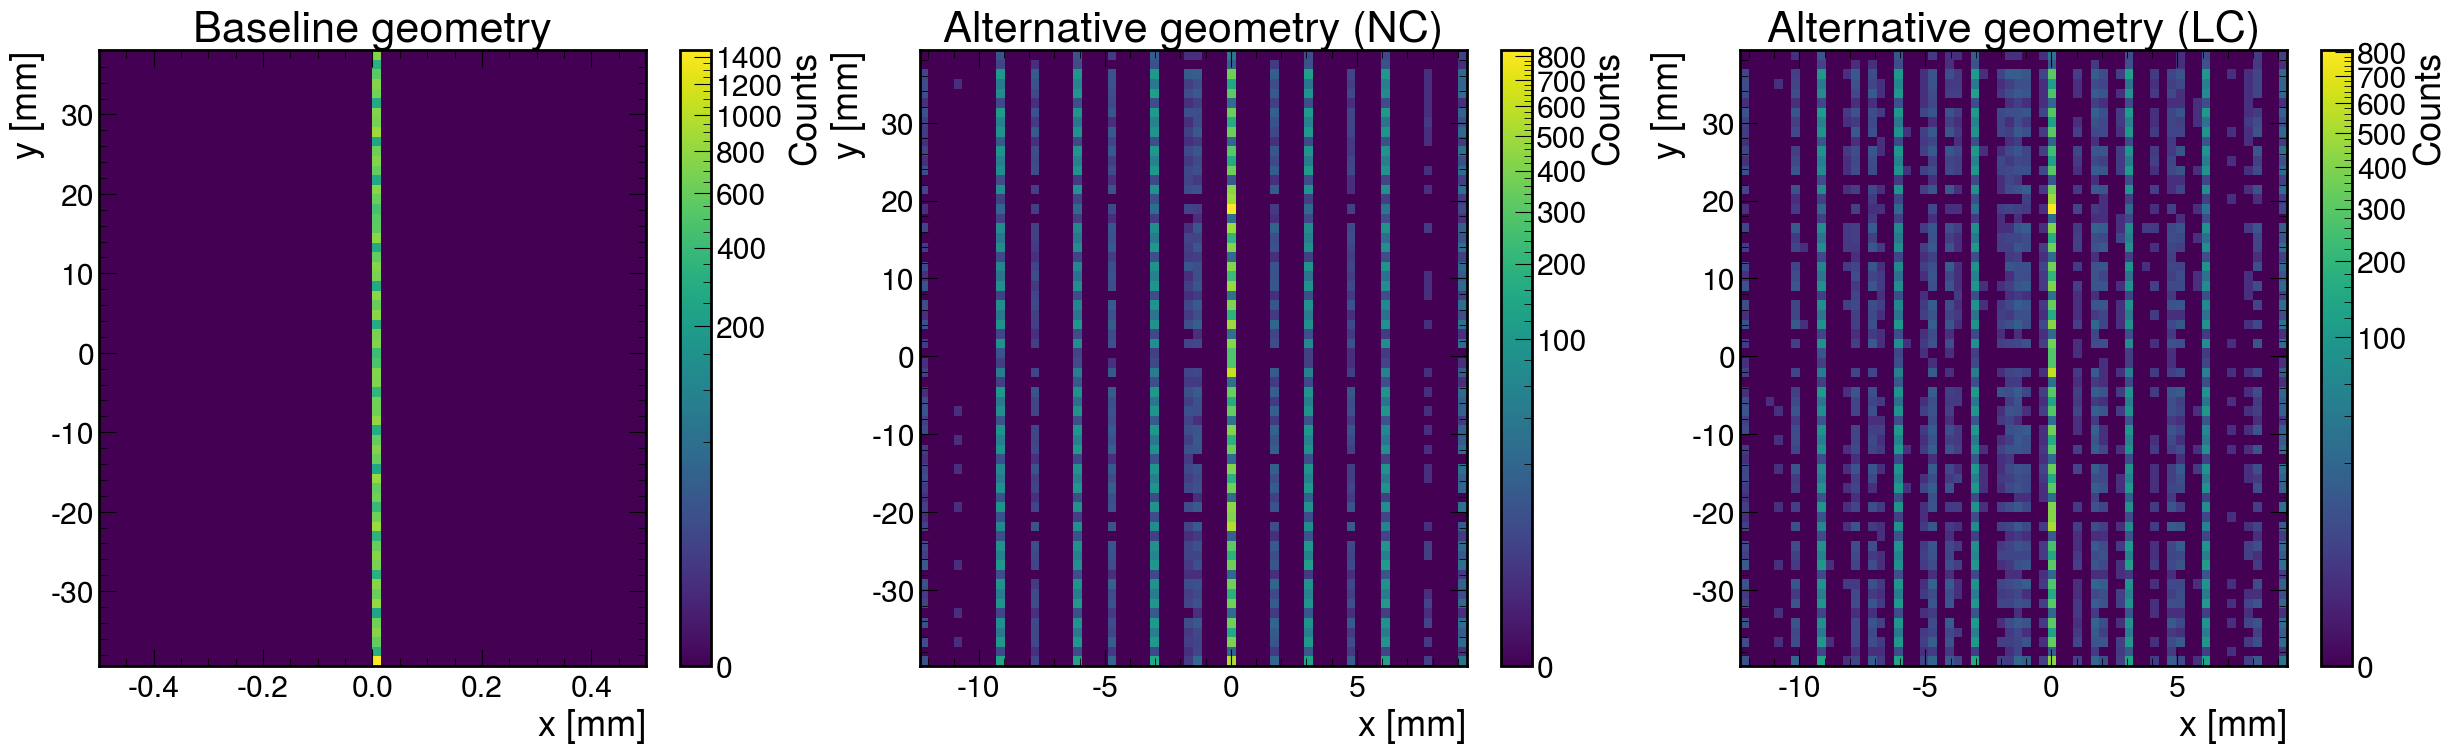

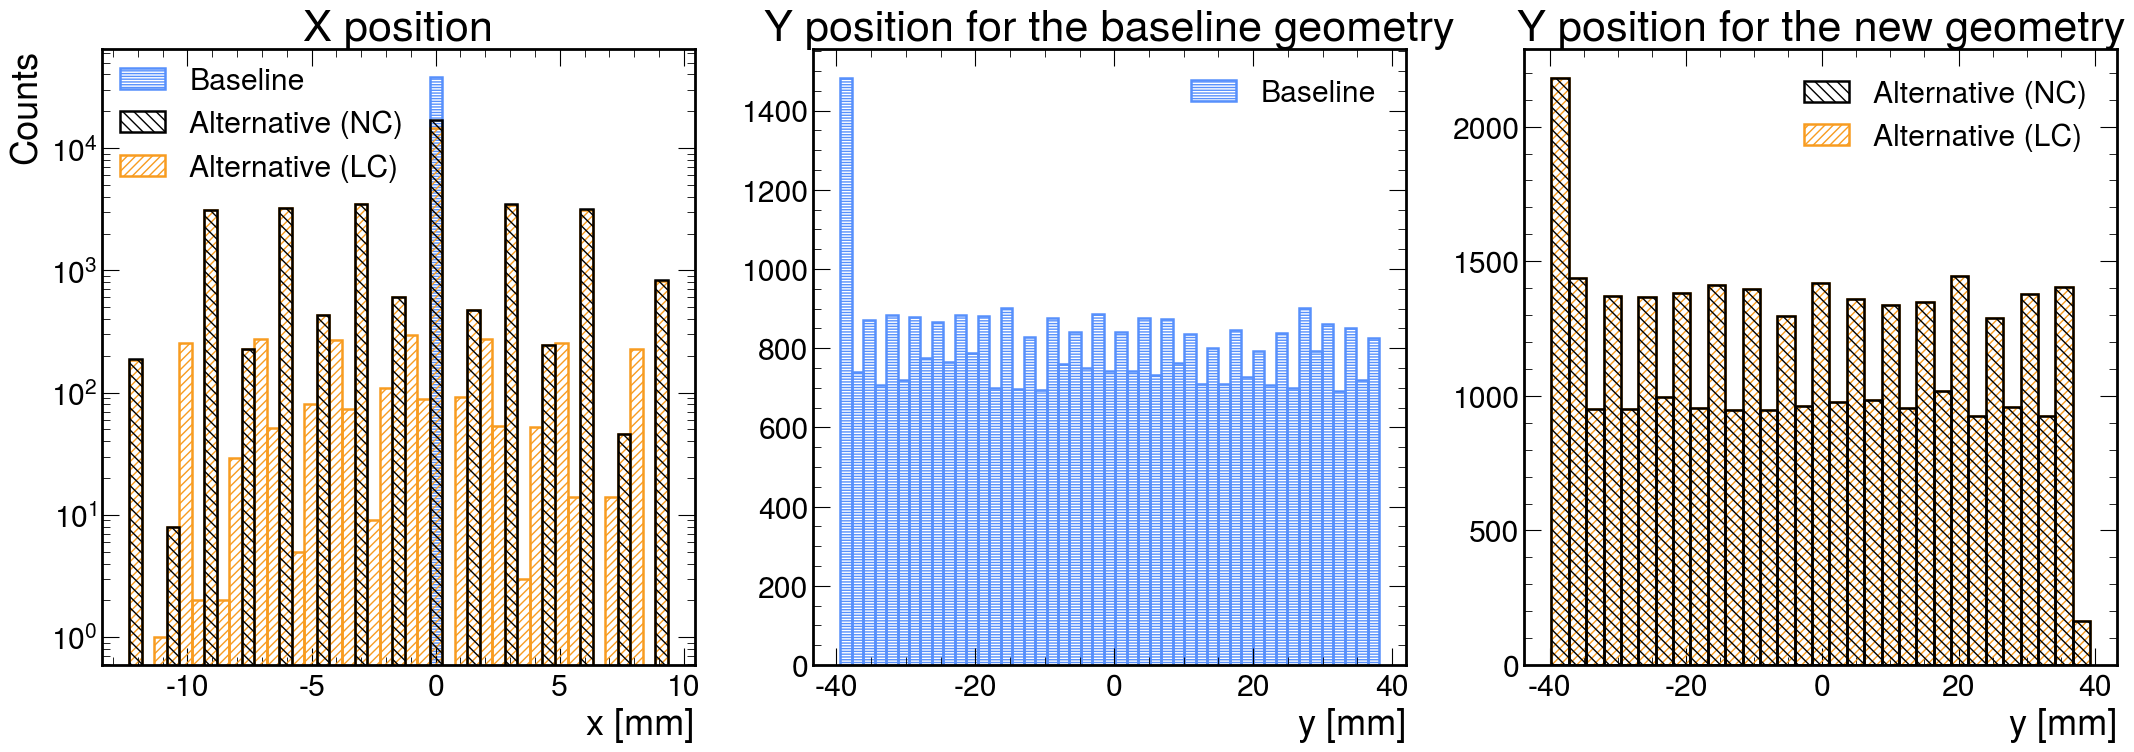

 max xc = -1.0


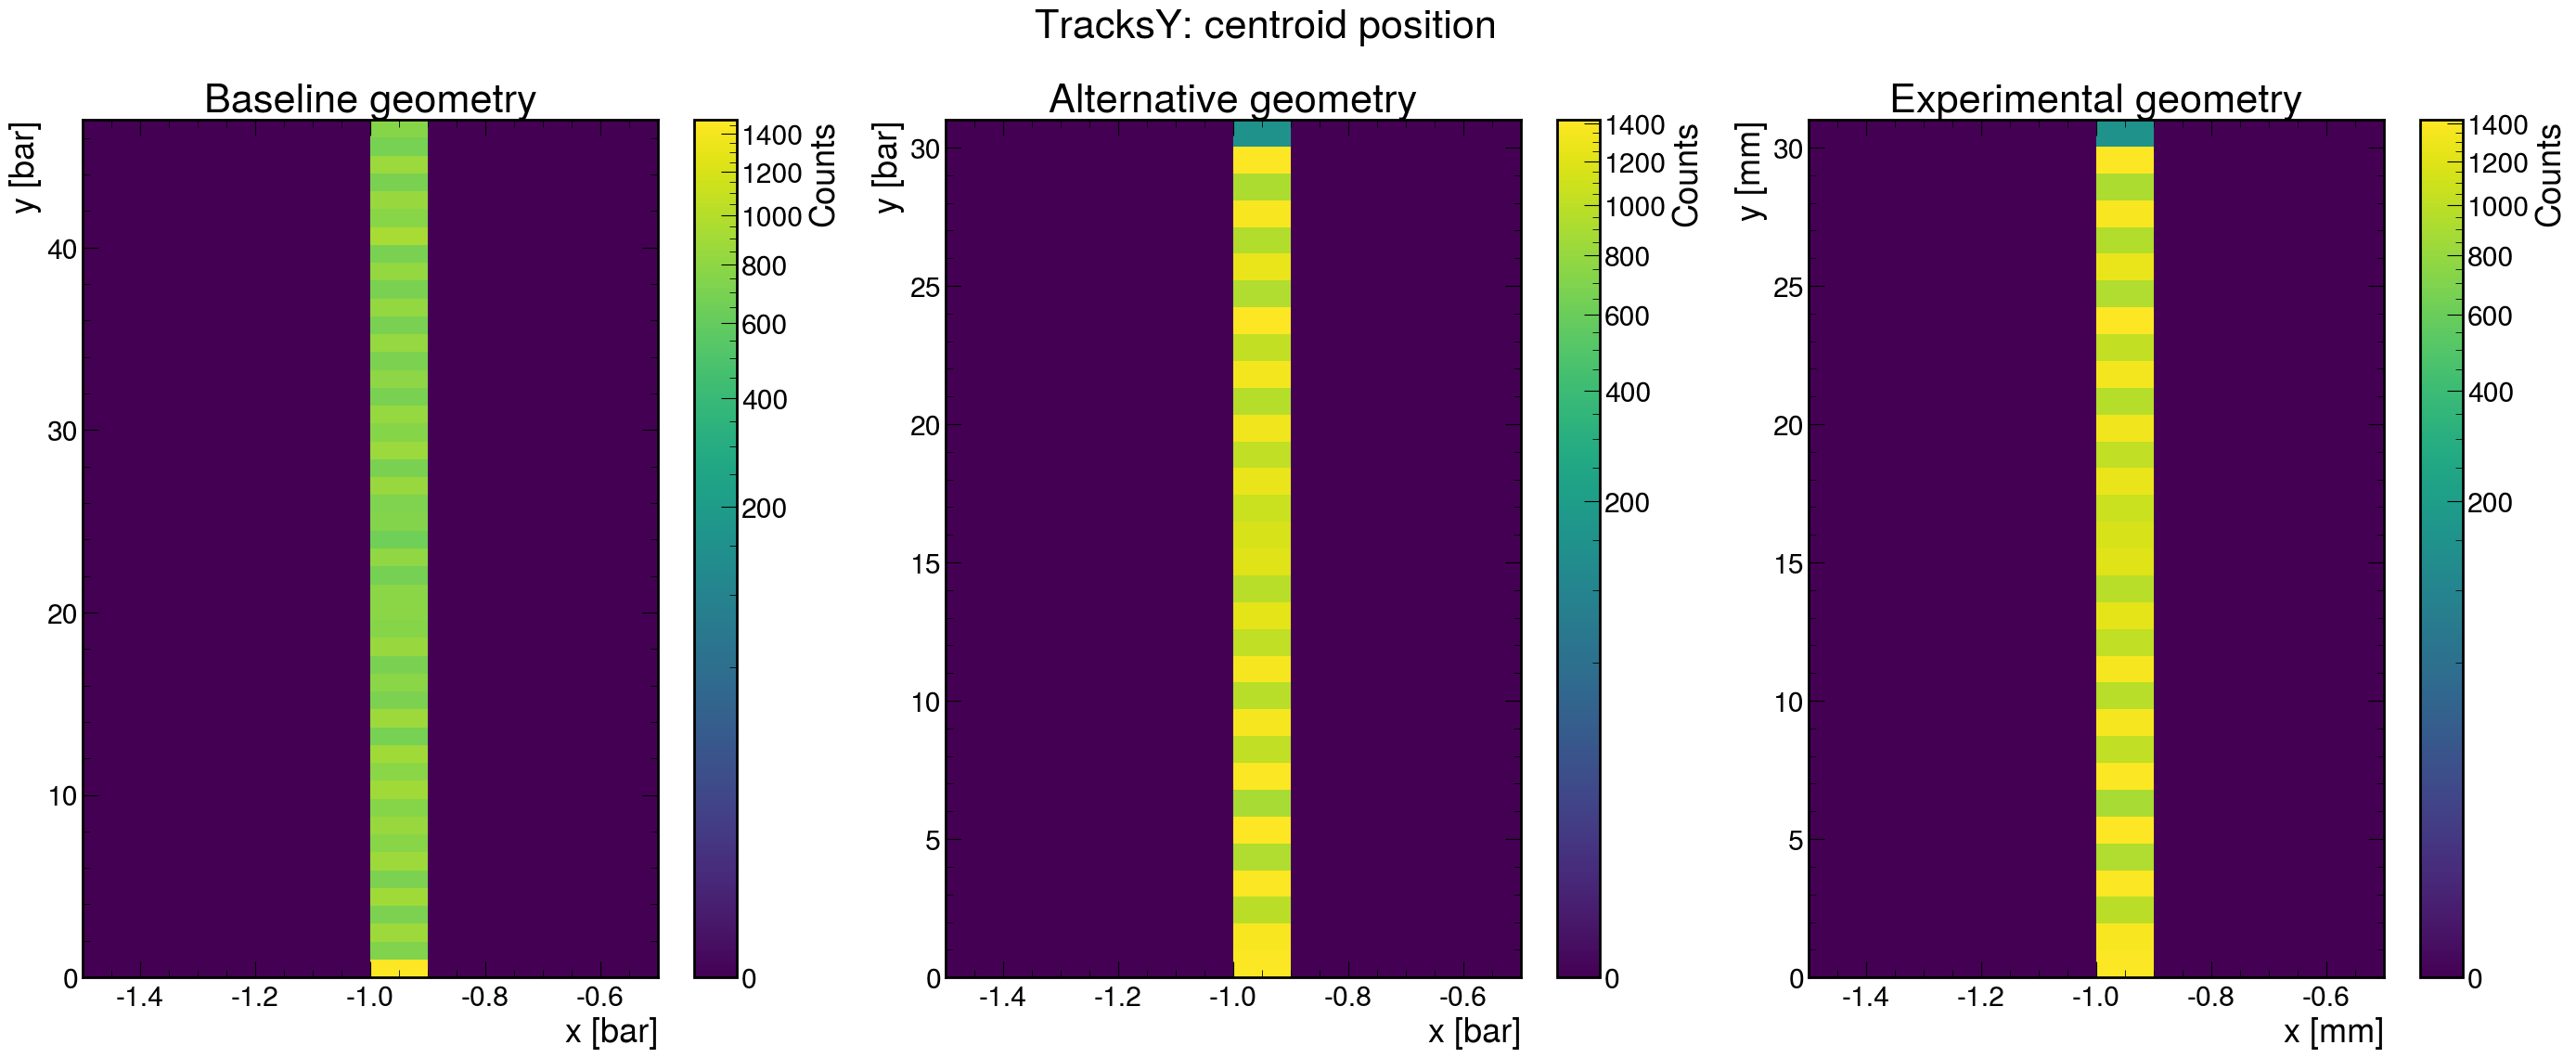

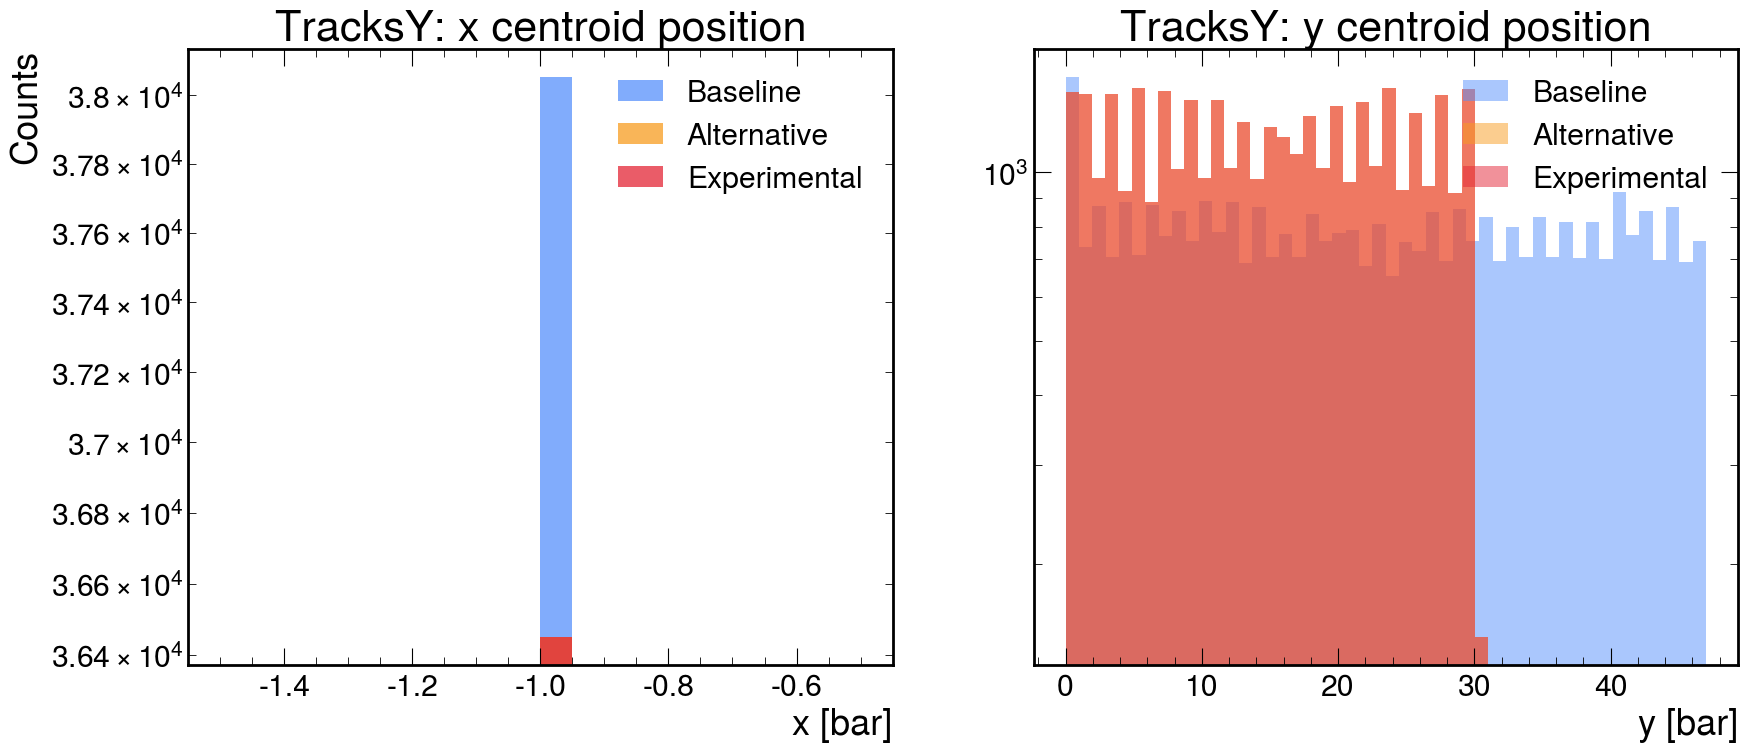

Baseline geometry before redution:  38053
Baseline geometry before redution, x_min:  15.0
Baseline geometry after redution 38053
Baseline geometry centroid:  38053
Alternative geometry before redution:  36450
Alternative geometry before redution, x_min:  1.5499992
Alternative geometry after redution 36450
Alternative geometry centroid:  36450
Experimental geometry before redution:  36450
Experimental geometry before redution, x_min:  1.5499992
Experimental geometry after redution 36450
Experimental geometry centroid:  36450


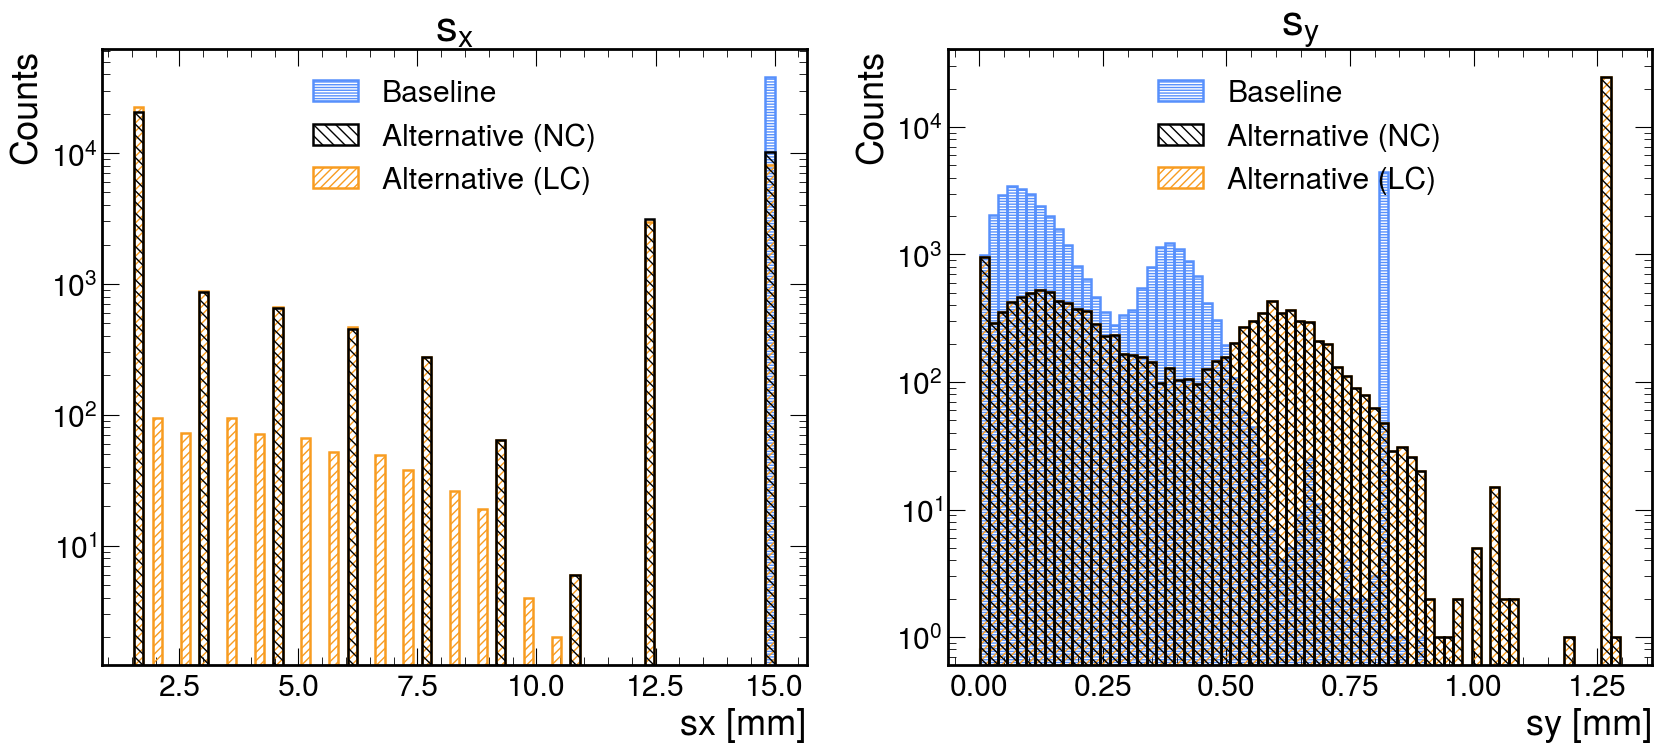

Baseline geometry: sx=(15.0,15.0) and sy=(0.0005264815408736467,0.890958309173584)
Alternative geometry: sx=(1.5499992370605469,15.0) and sy=(0.0023065474815666676,1.2964212894439697)
Experimental geometry: sx=(1.5499992370605469,15.0) and sy=(0.0023065474815666676,1.2964212894439697)

Alternative
sx>8: 13441; sx<8: 23009



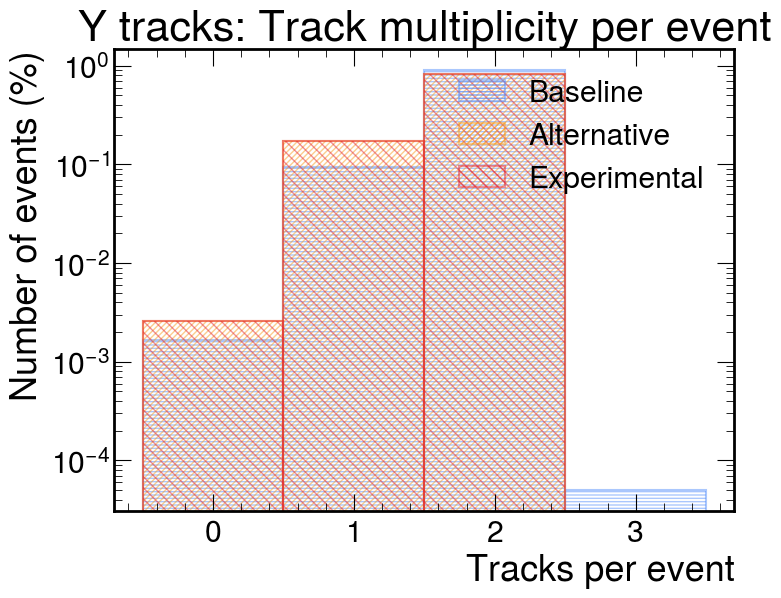

Number of 0-electron events:
- Baseline: 33, 0.165 % 
- Alternative: 52, 0.260 %
- Experimental: 52, 0.260 %
Number of 1-electron events:
- Baseline: 1882, 9.410 % 
- Alternative: 3446, 17.230 %
- Experimental: 3446, 17.230 %
Number of 2-electron events:
- Baseline: 18084, 90.420 % 
- Alternative: 16502, 82.510 %
- Experimental: 16502, 82.510 %
Number of 3-electron events:
- Baseline: 1, 0.005 % 
- Alternative: 0, 0.000 %
- Experimental: 0, 0.000 %



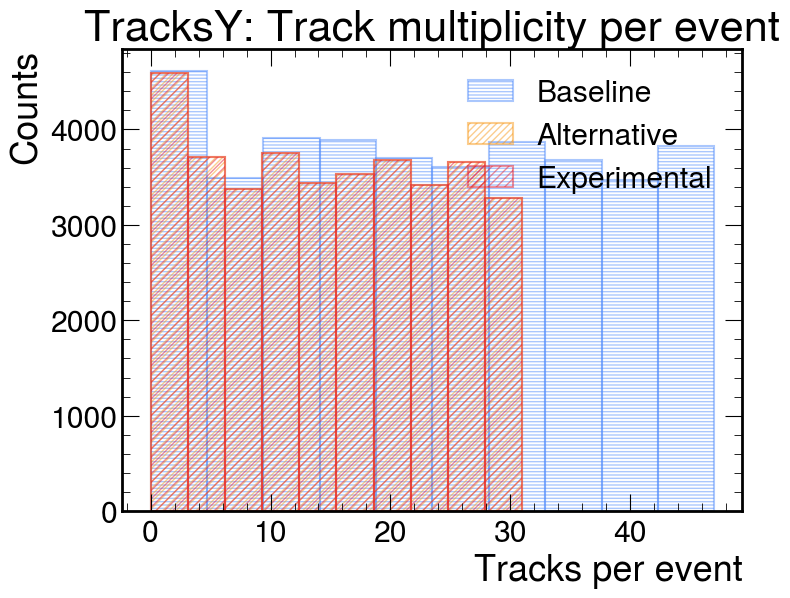

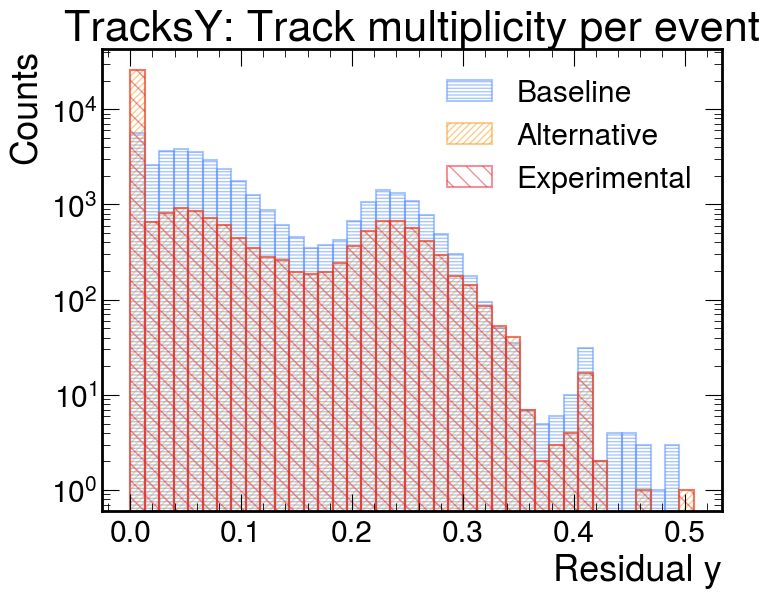

0.0 0.0 0.0


In [15]:
def flatten_tracks(ftr_pad):
    base = "TriggerPadTracksY_test/TriggerPadTracksY_test."
    
        # count tracks per event (this is your "w", but correct)
    count = np.array([len(ev) for ev in ftr_pad[base + "centroid_"]])

    x  = np.concatenate(ftr_pad[base + "x_"])
    y  = np.concatenate(ftr_pad[base + "y_"])
    z  = np.concatenate(ftr_pad[base + "z_"])
    xc = np.concatenate(ftr_pad[base + "centroid_x_"])
    yc = np.concatenate(ftr_pad[base + "centroid_y_"])
    sx = np.concatenate(ftr_pad[base + "sx_"])
    sy = np.concatenate(ftr_pad[base + "sy_"])
    c  = np.concatenate(ftr_pad[base + "centroid_"])
    r = np.concatenate(ftr_pad[base + "residual_"])

    return x, y, z, xc, yc, sx, sy, c, count,r

def flatten_tracks_(ftr_pad):
    base = "TriggerPadTracksY_overlay/TriggerPadTracksY_overlay."

    count = np.array([len(ev) for ev in ftr_pad[base + "centroid_"]])

    x  = np.concatenate(ftr_pad[base + "x_"])
    y  = np.concatenate(ftr_pad[base + "y_"])
    z  = np.concatenate(ftr_pad[base + "z_"])
    xc = np.concatenate(ftr_pad[base + "centroid_x_"])
    yc = np.concatenate(ftr_pad[base + "centroid_y_"])
    c  = np.concatenate(ftr_pad[base + "centroid_"])
    sx = np.concatenate(ftr_pad[base + "sx_"])
    sy = np.concatenate(ftr_pad[base + "sy_"])
    r = np.concatenate(ftr_pad[base + "residual_"])

    return x, y, z, xc, yc,sx, sy, c, count,r
    
x, y, z,xc,yc,sx,sy,c,count,r = flatten_tracks_(Ytr)
x_, y_, z_,xc_,yc_,sx_,sy_,c_,count_,r_ = flatten_tracks_(Ytr_alt)
x_1, y_1, z_1,xc_1,yc_1,sx_1,sy_1,c_1,count_1,r_1 = flatten_tracks_(Ytr_exp)


print("Baseline geometry before redution: ",len(x))

print("Baseline geometry before redution, x_min: ",min(x))
# Update to eliminate "bad points"
mn = -50
y = y[y >= mn]
x = x[(x >=mn)]
print("Baseline geometry after redution", len(x))
print("Baseline geometry centroid: ",len(xc))

print("Alternative geometry before redution: ",len(x_))

print("Alternative geometry before redution, x_min: ",min(x_))
# Update to eliminate "bad points"
mn = -50
y_ = y_[y_ >= mn]
x_ = x_[(x_ >=mn) ]
print("Alternative geometry after redution", len(x_))
print("Alternative geometry centroid: ",len(xc_))

print("Experimental geometry before redution: ",len(x_1))

print("Experimental geometry before redution, x_min: ",min(x_1))
# Update to eliminate "bad points"
mn = -50
y_1 = y_1[y_1 >= mn]
x_1 = x_1[(x_1 >=mn) ]
print("Experimental geometry after redution", len(x_1))
print("Experimental geometry centroid: ",len(xc_1))

print(len(x_1),len(y_1))


# 2D hit map (x-y position)
fig, axs = plt.subplots(1, 3, figsize=(30,8))

h0 = axs[0].hist2d(x, y, bins=(32*8)//4, norm=PowerNorm(gamma=0.3))
axs[0].set_xlabel("x [mm]")
axs[0].set_ylabel("y [mm]")
axs[0].set_title("Baseline geometry")

h1 = axs[1].hist2d(x_, y_, bins=(32*8)//4, norm=PowerNorm(gamma=0.3))
axs[1].set_xlabel("x [mm]")
axs[1].set_ylabel("y [mm]")
axs[1].set_title("Alternative geometry (NC)")

h2 = axs[2].hist2d(x_1, y_1, bins=(32*8)//4, norm=PowerNorm(gamma=0.3))
axs[2].set_xlabel("x [mm]")
axs[2].set_ylabel("y [mm]")
axs[2].set_title("Alternative geometry (LC)")

fig.colorbar(h0[3], ax=axs[0], label="Counts")
fig.colorbar(h1[3], ax=axs[1], label="Counts")
fig.colorbar(h2[3], ax=axs[2], label="Counts")

plt.savefig('plots/2elec/TracksY_position2D',
            dpi=300, bbox_inches="tight")

plt.show()

fig, axs = plt.subplots(1, 3, figsize=(26,8))
# ---- Left: original ----
min_ = min(min(x_),min(x_1))
max_ = max(max(x_),max(x_1))
bins=np.linspace(min_,max_,44)

axs[0].hist(x, bins=bins, histtype='bar', facecolor='none',
            edgecolor='C0', hatch='------', linewidth=1.8, alpha=1, zorder=1,
            label='Baseline')

axs[0].hist(x_, bins=bins, histtype='bar', facecolor='none',
            edgecolor='black', hatch='\\\\\\', linewidth=1.8, alpha=1, zorder=3,
            label='Alternative (NC)')

axs[0].hist(x_1, bins=bins, histtype='bar', facecolor='none',
            edgecolor='C1', hatch='////', linewidth=1.8, alpha=1, zorder=2,
            label='Alternative (LC)')

axs[0].set_xlabel("x [mm]")
axs[0].set_ylabel("Counts")
axs[0].set_yscale('log')
axs[0].set_title(f"X position")
axs[0].legend(loc='upper left', bbox_to_anchor=(-0.02,1.02))

min_ = min(y)
max_ = max(y)
bins=np.linspace(min_,max_,48)

axs[1].hist(y, bins=bins, histtype='bar', facecolor='none',
            edgecolor='C0', hatch='------', linewidth=1.8, alpha=1, zorder=1,
            label='Baseline')

axs[1].set_xlabel("y [mm]")
axs[1].set_title(f"Y position for the baseline geometry")
axs[1].legend()

min_ = min(min(y_),min(y_1))
max_ = max(max(y_),max(y_1))
bins=np.linspace(min_,max_,32)

axs[2].hist(y_, bins=bins, histtype='bar', facecolor='none',
            edgecolor='black', hatch='\\\\\\', linewidth=1.8,
            alpha=1, zorder=3,
            label='Alternative (NC)')

axs[2].hist(y_, bins=bins, histtype='bar', facecolor='none',
            edgecolor='C1', hatch='////', linewidth=1.8,
            alpha=1, zorder=2,
            label='Alternative (LC)')

axs[2].set_xlabel("y [mm]")
axs[2].set_title(f"Y position for the new geometry")
axs[2].legend()

# fig.suptitle("TracksY: Position comparasion for 2 electrons/event")
plt.savefig('plots/2elec/TracksY_position', dpi=300, bbox_inches="tight")
#plt.tight_layout()
plt.show()
# fig, axs = plt.subplots(1, 2, figsize=(20,8))
# # ---- Left: original ----
# axs[0].hist(x,  bins=43, alpha=0.5, label='Baseline')
# axs[0].hist(x_, bins=43, alpha=0.5, label='Alternative')
# axs[0].hist(x_1, bins=43, alpha=0.5, label='Experimental')
# axs[0].set_xlabel("x [mm]")
# axs[0].set_ylabel("Counts")
# axs[0].set_yscale('log')
# axs[0].set_title(f"TriggerPadTracksY: x position (all events)")
# axs[0].legend()

# # ---- Right: centroids only ----
# axs[1].hist(y,  bins='auto', alpha=0.5, label='Baseline')
# axs[1].hist(y_, bins='auto', alpha=0.5, label='Alternative')
# axs[1].hist(y_1, bins='auto', alpha=0.5, label='Experimental')
# axs[1].set_xlabel("y [mm]")
# axs[1].set_title(f"TriggerPadTracksY: y position (all events)")
# axs[1].legend()

# #plt.tight_layout()
# plt.show()

text=f""" max xc = {max(xc_)}"""
print(text)

# 2D hit map (x-y position) ------- Centroids --------------
fig, axs = plt.subplots(1, 3, figsize=(34,12))
fig.suptitle("TracksY: centroid position") #fontsize=18)
h0 = axs[0].hist2d(xc, yc, bins=(10,48),norm=PowerNorm(gamma=0.3))
axs[0].set_xlabel("x [bar]")
axs[0].set_ylabel("y [bar]")
axs[0].set_title(f"Baseline geometry")

h1 = axs[1].hist2d(xc_, yc_, bins=(10,32) ,norm=PowerNorm(gamma=0.3))
axs[1].set_xlabel("x [bar]")
axs[1].set_ylabel("y [bar]")
axs[1].set_title(f"Alternative geometry")

h2 = axs[2].hist2d(xc_1, yc_1, bins=(10,32),norm=PowerNorm(gamma=0.3))
axs[2].set_xlabel("x [mm]")
axs[2].set_ylabel("y [mm]")
axs[2].set_title(f"Experimental geometry")

fig.colorbar(h0[3], ax=axs[0], label="Counts")
fig.colorbar(h1[3], ax=axs[1], label="Counts")
fig.colorbar(h2[3], ax=axs[2], label="Counts")

#plt.tight_layout() do not works with both
plt.show()

fig, axs = plt.subplots(1, 2, figsize=(20,8))

# ---- Left: original ----
axs[0].hist(xc,  bins=20, alpha=0.75, label='Baseline')
axs[0].hist(xc_, bins=20, alpha=0.75, label='Alternative')
axs[0].hist(xc_1, bins=20, alpha=0.75, label='Experimental')
axs[0].set_xlabel("x [bar]")
axs[0].set_ylabel("Counts")
axs[0].set_yscale('log')
axs[0].set_title(f"TracksY: x centroid position")
axs[0].legend()

# ---- Right: centroids only ----
axs[1].hist(yc,  bins=48, alpha=0.5, label='Baseline')
axs[1].hist(yc_, bins=32, alpha=0.5, label='Alternative')
axs[1].hist(yc_1, bins=32, alpha=0.5, label='Experimental')
axs[1].set_xlabel("y [bar]")
axs[1].set_yscale('log')
axs[1].set_title(f"TracksY: y centroid position")
axs[1].legend()

#plt.tight_layout()
plt.show()

print("Baseline geometry before redution: ",len(sx))

print("Baseline geometry before redution, x_min: ",min(sx))
# Update to eliminate "bad points"
mn = -50
sy = sy[sy >= mn]
sx = sx[(sx>=mn) ]
print("Baseline geometry after redution", len(sx))
print("Baseline geometry centroid: ",len(sx))

print("Alternative geometry before redution: ",len(sx_))

print("Alternative geometry before redution, x_min: ",min(sx_))
# Update to eliminate "bad points"
mn = -50
sy_ = sy_[sy_ >= mn]
sx_ = sx_[(sx_ >=mn) ]
print("Alternative geometry after redution", len(sx_))
print("Alternative geometry centroid: ",len(sx_))

print("Experimental geometry before redution: ",len(sx_1))

print("Experimental geometry before redution, x_min: ",min(sx_1))
# Update to eliminate "bad points"
mn = -50
sy_1 = sy_1[sy_1 >= mn]
sx_1 = sx_1[(sx_1 >=mn) ]
print("Experimental geometry after redution", len(sx_1))
print("Experimental geometry centroid: ",len(sx_1))


fig, axs = plt.subplots(1, 2, figsize=(20,8))

# ---- Left: original ----
min_ = min(min(sx),min(sx_),min(sx_1))
max_ = max(max(sx),max(sx_),max(sx_1))
bins=np.linspace(min_,max_,70)
axs[0].hist(sx, bins=bins, histtype='bar', facecolor='none',
            edgecolor='C0', hatch='------', linewidth=1.8, alpha=1, zorder=1,
            label='Baseline')

axs[0].hist(sx_, bins=bins, histtype='bar', facecolor='none',
            edgecolor='black', hatch='\\\\\\', linewidth=1.8, alpha=1, zorder=3,
            label='Alternative (NC)')

axs[0].hist(sx_1, bins=bins, histtype='bar', facecolor='none',
            edgecolor='C1', hatch='////', linewidth=1.8, alpha=1, zorder=2,
            label='Alternative (LC)')
axs[0].set_xlabel("sx [mm]")
axs[0].set_ylabel("Counts")
axs[0].set_yscale('log')
axs[0].set_title(f"$s_x$")
axs[0].legend()

# ---- Right: centroids only ----
min_ = min(min(sy),min(sy_),min(sy_1))
max_ = max(max(sy),max(sy_),max(sy_1))
bins=np.linspace(min_,max_,70)
axs[1].hist(sy, bins=bins, histtype='bar', facecolor='none',
            edgecolor='C0', hatch='------', linewidth=1.8, alpha=1, zorder=1,
            label='Baseline')

axs[1].hist(sy_, bins=bins, histtype='bar', facecolor='none',
            edgecolor='black', hatch='\\\\\\', linewidth=1.8, alpha=1, zorder=3,
            label='Alternative (NC)')

axs[1].hist(sy_1, bins=bins, histtype='bar', facecolor='none',
            edgecolor='C1', hatch='////', linewidth=1.8, alpha=1, zorder=2,
            label='Alternative (LC)')
axs[1].set_xlabel("sy [mm]")
axs[1].set_ylabel("Counts")
axs[1].set_yscale('log')
axs[1].set_title(f"$s_y$")
axs[1].legend()

plt.savefig('plots/2elec/TracksY_uncertainty', dpi=300, bbox_inches="tight")
#plt.tight_layout()
plt.show()

text= f"""Baseline geometry: sx=({min(sx)},{max(sx)}) and sy=({min(sy)},{max(sy)})
Alternative geometry: sx=({min(sx_)},{max(sx_)}) and sy=({min(sy_)},{max(sy_)})
Experimental geometry: sx=({min(sx_1)},{max(sx_1)}) and sy=({min(sy_1)},{max(sy_1)})

Alternative
sx>8: {np.sum(sx_>8)}; sx<8: {np.sum(sx_<8)}
"""

print(text)

# Define bins centered on integers
max_count = int(max(count.max(), count_.max(),count_1.max()))
bins = np.arange(-0.5, max_count + 1.5, 1)

# Plot
plt.figure(figsize=(8,6))

plt.hist(count,  bins=bins, alpha=0.5,  histtype='bar', facecolor='none',
            edgecolor='C0', hatch='-----', linewidth=1.5,label='Baseline',density=True)
plt.hist(count_, bins=bins, alpha=0.5,  histtype='bar', facecolor='none',
            edgecolor='C1', hatch='//////', linewidth=1.5,label='Alternative',density=True)
plt.hist(count_1, bins=bins, alpha=0.5,  histtype='bar', facecolor='none',
            edgecolor='C2', hatch='\\\\\\', linewidth=1.5,label='Experimental',density=True)


plt.xlabel("Tracks per event")
plt.ylabel("Number of events (%)")
plt.yscale('log')
plt.title("Y tracks: Track multiplicity per event")
plt.legend()

plt.show()

text = f"""Number of 0-electron events:
- Baseline: {np.sum(count == 0)}, {np.sum(count==0)*100/len(count):.3f} % 
- Alternative: {np.sum(count_ == 0)}, {np.sum(count_==0)*100/len(count_):.3f} %
- Experimental: {np.sum(count_1 == 0)}, {np.sum(count_==0)*100/len(count_1):.3f} %
Number of 1-electron events:
- Baseline: {np.sum(count == 1)}, {np.sum(count==1)*100/len(count):.3f} % 
- Alternative: {np.sum(count_ == 1)}, {np.sum(count_==1)*100/len(count_):.3f} %
- Experimental: {np.sum(count_1 == 1)}, {np.sum(count_1==1)*100/len(count_1):.3f} %
Number of 2-electron events:
- Baseline: {np.sum(count == 2)}, {np.sum(count==2)*100/len(count):.3f} % 
- Alternative: {np.sum(count_ == 2)}, {np.sum(count_==2)*100/len(count_):.3f} %
- Experimental: {np.sum(count_1 == 2)}, {np.sum(count_1==2)*100/len(count_1):.3f} %
Number of 3-electron events:
- Baseline: {np.sum(count == 3)}, {np.sum(count==3)*100/len(count):.3f} % 
- Alternative: {np.sum(count_ == 3)}, {np.sum(count_==3)*100/len(count_):.3f} %
- Experimental: {np.sum(count_1 == 3)}, {np.sum(count_1==3)*100/len(count_1):.3f} %
"""

print(text)

# Plot
plt.figure(figsize=(8,6))

plt.hist(c, alpha=0.5, histtype='bar', facecolor='none',
            edgecolor='C0', hatch='-----', linewidth=1.5,label='Baseline')#,density=True)
plt.hist(c_, alpha=0.5, histtype='bar', facecolor='none',
            edgecolor='C1', hatch='/////', linewidth=1.5,label='Alternative')#,density=True)
plt.hist(c_1, alpha=0.5, histtype='bar', facecolor='none',
            edgecolor='C2', hatch='////', linewidth=1.5,label='Experimental')#,density=True)


plt.xlabel("Tracks per event")
plt.ylabel("Counts")
# plt.yscale('log')
plt.title("TracksY: Track multiplicity per event")
plt.legend()

plt.show()

# Plot
min_ = min(min(r),min(r_),min(r_1))
max_ = max(max(r_1),max(r_),max(r_1))
bins=np.linspace(min_,max_,40)

plt.figure(figsize=(8,6))

plt.hist(r, bins=bins,alpha=0.5, histtype='bar', facecolor='none',
            edgecolor='C0', hatch='-----', linewidth=1.5,label='Baseline')#,density=True)
plt.hist(r_,bins=bins, alpha=0.5, histtype='bar', facecolor='none',
            edgecolor='C1', hatch='/////', linewidth=1.5,label='Alternative')#,density=True)
plt.hist(r_1, bins=bins,alpha=0.5, histtype='bar', facecolor='none',
            edgecolor='C2', hatch='\\\\', linewidth=1.5,label='Experimental')#,density=True)


plt.xlabel("Residual y")
plt.ylabel("Counts")
plt.yscale('log')
plt.title("TracksY: Track multiplicity per event")
plt.legend()

plt.show()

print(min(r),min(r_),min(r_1))

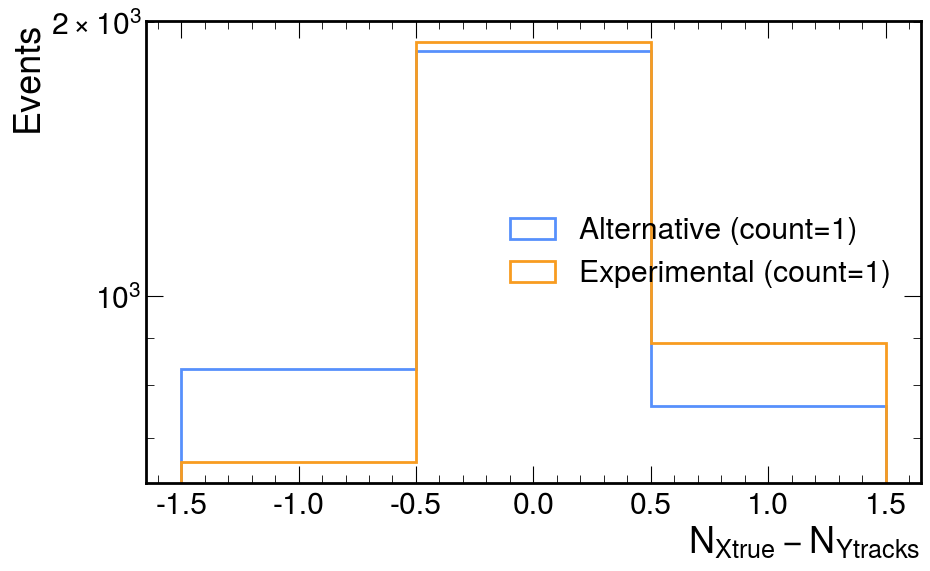

In [20]:
# Select specific values
selected_count_alt = 1
selected_count_exp = 1

# Masks
mask_alt = (count_ == selected_count_alt)
mask_exp = (count_1 == selected_count_exp)

# Differences only for selected events
diff_alt = XcountTrue_[mask_alt] - count_[mask_alt]
diff_exp = XcountTrue_1[mask_exp] - count_1[mask_exp]

# Histogram bins
bins = np.arange(
    min(diff_alt.min(), diff_exp.min()) - 0.5,
    max(diff_alt.max(), diff_exp.max()) + 1.5,
    1
)

plt.figure(figsize=(10,6))

plt.hist(
    diff_alt,
    bins=bins,
    histtype="step",
    linewidth=2,
    label=f"Alternative (count={selected_count_alt})"
)

plt.hist(
    diff_exp,
    bins=bins,
    histtype="step",
    linewidth=2,
    label=f"Experimental (count={selected_count_exp})"
)

plt.xlabel(r"$N_{\mathrm{Xtrue}} - N_{\mathrm{Ytracks}}$")
plt.ylabel("Events")
plt.yscale("log")

plt.legend()

plt.savefig(
    "plots/count_difference_filtered.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [16]:
x, y, z,xc,yc,sx,sy,c,count,r= flatten_tracks_(Ytr)
x_, y_, z_,xc_,yc_,sx_,sy_,c_,count_,r_ = flatten_tracks_(Ytr_alt)
x_1, y_1, z_1,xc_1,yc_1,sx_1,sy_1,c_1,count_1,r_1 = flatten_tracks_(Ytr_exp)

text = f""" - Baseline geometry
sx={np.mean(sx):.2f}
sy={np.mean(sy):.2f}

 - Alternative geometry
sx={np.mean(sx_):.2f}
sy={np.mean(sy_):.2f}

 - Experimental geometry
sx={np.mean(sx_1):.2f}
sy={np.mean(sy_1):.2f}
"""
print(text)

 - Baseline geometry
sx=15.00
sy=0.25

 - Alternative geometry
sx=6.47
sy=0.97

 - Experimental geometry
sx=5.66
sy=0.97



In [54]:
x, y, z, xc, yc, sx, sy, c, count = flatten_tracks_(Ytr)
x_, y_, z_, xc_, yc_, sx_, sy_, c_, count_ = flatten_tracks_(Ytr_alt)
x_1, y_1, z_1, xc_1, yc_1, sx_1, sy_1, c_1, count_1 = flatten_tracks_(Ytr_exp)

mask = (c != yc)

print("Indices:", np.where(mask)[0])
print("c values:", c[mask])
print("yc values:", yc[mask])

Indices: []
c values: []
yc values: []


In [31]:
x, y, z, xc, yc, sx, sy, c, count = flatten_tracks_(Ytr)
x_, y_, z_, xc_, yc_, sx_, sy_, c_, count_ = flatten_tracks_(Ytr_alt)
x_1, y_1, z_1, xc_1, yc_1, sx_1, sy_1, c_1, count_1 = flatten_tracks_(Ytr_exp)

event_id   = np.concatenate([np.full(n, i) for i, n in enumerate(count)])
event_id_  = np.concatenate([np.full(n, i) for i, n in enumerate(count_)])
event_id_1 = np.concatenate([np.full(n, i) for i, n in enumerate(count_1)])

# Keep original full arrays
event_id_full   = event_id.copy()
event_id_full_  = event_id_.copy()
event_id_full_1 = event_id_1.copy()

x_full, y_full, z_full, xc_full, yc_full, sx_full, sy_full, c_full = x, y, z, xc, yc, sx, sy, c
x_full_, y_full_, z_full_, xc_full_, yc_full_, sx_full_, sy_full_, c_full_ = x_, y_, z_, xc_, yc_, sx_, sy_, c_
x_full_1, y_full_1, z_full_1, xc_full_1, yc_full_1, sx_full_1, sy_full_1, c_full_1 = x_1, y_1, z_1, xc_1, yc_1, sx_1, sy_1, c_1

# --- event-level masks (count == 2) ---
event_mask   = (count   == 1)
event_mask_  = (count_  == 1)
event_mask_1 = (count_1 == 1)

# --- condition tracks ---
track_mask   = np.concatenate([np.full(n, m) for n, m in zip(count,   event_mask)])   & (sx > 14) #& (y   > -37)
track_mask_  = np.concatenate([np.full(n, m) for n, m in zip(count_,  event_mask_)])  #& (yc_  == 1) & (y_  > -37)
track_mask_1 = np.concatenate([np.full(n, m) for n, m in zip(count_1, event_mask_1)]) #& (yc_1 == 1) & (y_1 > -37)

# Event IDs that have at least one track matching the condition
selected_events   = np.unique(event_id[track_mask])
selected_events_  = np.unique(event_id_[track_mask_])
selected_events_1 = np.unique(event_id_1[track_mask_1])

# Now keep ALL tracks from those event_ids
track_mask   = np.isin(event_id_full,   selected_events)
track_mask_  = np.isin(event_id_full_,  selected_events_)
track_mask_1 = np.isin(event_id_full_1, selected_events_1)

event_id   = event_id_full[track_mask]
event_id_  = event_id_full_[track_mask_]
event_id_1 = event_id_full_1[track_mask_1]

# Apply
x, y, z, xc, yc, sx, sy, c = [arr[track_mask] for arr in (x_full, y_full, z_full, xc_full, yc_full, sx_full, sy_full, c_full)]
x_, y_, z_, xc_, yc_, sx_, sy_, c_ = [arr[track_mask_] for arr in (x_full_, y_full_, z_full_, xc_full_, yc_full_, sx_full_, sy_full_, c_full_)]
x_1, y_1, z_1, xc_1, yc_1, sx_1, sy_1, c_1 = [arr[track_mask_1] for arr in (x_full_1, y_full_1, z_full_1, xc_full_1, yc_full_1, sx_full_1, sy_full_1, c_full_1)]

# Sort by event_id
idx   = np.argsort(event_id)
idx_  = np.argsort(event_id_)
idx_1 = np.argsort(event_id_1)

event_id   = event_id[idx]
event_id_  = event_id_[idx_]
event_id_1 = event_id_1[idx_1]

x, y, z, xc, yc, sx, sy, c = [arr[idx] for arr in (x, y, z, xc, yc, sx, sy, c)]
x_, y_, z_, xc_, yc_, sx_, sy_, c_ = [arr[idx_] for arr in (x_, y_, z_, xc_, yc_, sx_, sy_, c_)]
x_1, y_1, z_1, xc_1, yc_1, sx_1, sy_1, c_1 = [arr[idx_1] for arr in (x_1, y_1, z_1, xc_1, yc_1, sx_1, sy_1, c_1)]

text = f""" - Baseline geometry
Length of values: {len(x)}\nevent_id: {event_id}\nx: {x}\ny: {y}\nxc: {xc}\nyc: {yc}\nsx: {sx}\nsy:{sy}

 - Alternative geometry
Length of values: {len(x_)}\nevent_id: {event_id_}\nx: {x_}\ny: {y_}\nxc: {xc_}\nyc: {yc_}\nsx: {sx_}\nsy:{sy_}

 - Experimental geometry
Length of values: {len(x_1)}\nevent_id: {event_id_1}\nx: {x_1}\ny: {y_1}\nxc: {xc_1}\nyc: {yc_1}\nsx: {sx_1}\nsy:{sy_1}
"""
print(text)

 - Baseline geometry
Length of values: 1882
event_id: [    8    44    80 ... 19981 19995 19996]
x: [0. 0. 0. ... 0. 0. 0.]
y: [-15.243401  28.922325  -1.765377 ... -25.218466 -14.985996   5.929306]
xc: [-1. -1. -1. ... -1. -1. -1.]
yc: [14.670665 41.43777  22.839163 ...  8.625171 14.826667 27.502607]
sx: [15. 15. 15. ... 15. 15. 15.]
sy:[0.07357058 0.17891273 0.37531033 ... 0.44529122 0.40446544 0.10107554]

 - Alternative geometry
Length of values: 3446
event_id: [    0     2     4 ... 19995 19997 19998]
x: [-1.5         0.05000019  0.         ...  3.1500006  -9.25
 -9.25      ]
y: [ 27.792473 -23.877962  18.09377  ... -23.028887 -39.75       9.83342 ]
xc: [-1. -1. -1. ... -1. -1. -1.]
yc: [26.487244   6.2243285 22.683832  ...  6.557299   0.        19.444479 ]
sx: [ 1.5500002  1.55      15.        ...  1.55       1.55       1.55     ]
sy:[0.08641155 0.8089835  0.23435065 ... 0.11802475 1.275      0.25064328]

 - Experimental geometry
Length of values: 3446
event_id: [    0     2     4

In [26]:
x, y, z,xc,yc,sx,sy,c,count = flatten_tracks_(Ytr)
x_, y_, z_,xc_,yc_,sx_,sy_,c_,count_ = flatten_tracks_(Ytr_alt)
x_1, y_1, z_1,xc_1,yc_1,sx_1,sy_1,c_1,count_1 = flatten_tracks_(Ytr_exp)

# Round to 2 decimals
x,  y,  z,  xc,  yc,  sx,  sy,  c  = [np.round(arr, 2) for arr in (x,  y,  z,  xc,  yc,  sx,  sy,  c)]
x_, y_, z_, xc_, yc_, sx_, sy_, c_ = [np.round(arr, 2) for arr in (x_, y_, z_, xc_, yc_, sx_, sy_, c_)]
x_1,y_1,z_1,xc_1,yc_1,sx_1,sy_1,c_1= [np.round(arr, 2) for arr in (x_1,y_1,z_1,xc_1,yc_1,sx_1,sy_1,c_1)]

# Build event_id (track-level)
event_id   = np.concatenate([np.full(n, i) for i, n in enumerate(count)])
event_id_  = np.concatenate([np.full(n, i) for i, n in enumerate(count_)])
event_id_1 = np.concatenate([np.full(n, i) for i, n in enumerate(count_1)])

# --- CONDITION (track-level) ---
track_cond   = (sx == .15)
track_cond_  = (sx_ < -99)
track_cond_1 = (x_1 < -99)

# --- GET EVENTS THAT MATCH ---
selected_events   = np.unique(event_id[track_cond])
selected_events_  = np.unique(event_id_[track_cond_])
selected_events_1 = np.unique(event_id_1[track_cond_1])

# --- NOW SELECT ALL TRACKS FROM THOSE EVENTS ---
track_mask   = np.isin(event_id,   selected_events)
track_mask_  = np.isin(event_id_,  selected_events_)
track_mask_1 = np.isin(event_id_1, selected_events_1)

# Apply
event_id   = event_id[track_mask]
event_id_  = event_id_[track_mask_]
event_id_1 = event_id_1[track_mask_1]

x, y, z, xc, yc, sx, sy, c = [arr[track_mask] for arr in (x, y, z, xc, yc, sx, sy, c)]
x_, y_, z_, xc_, yc_, sx_, sy_, c_ = [arr[track_mask_] for arr in (x_, y_, z_, xc_, yc_, sx_, sy_, c_)]
x_1, y_1, z_1, xc_1, yc_1, sx_1, sy_1, c_1 = [arr[track_mask_1] for arr in (x_1, y_1, z_1, xc_1, yc_1, sx_1, sy_1, c_1)]

text = f""" - Baseline geometry
Length of values: {len(x)}\nevent_id: {event_id[:10]}\nx: {x}\ny: {y[:10]}\nxc: {xc}\nyc: {yc[:10]}\nsx: {sx}\nsy:{sy}

 - Alternative geometry
Length of values: {len(x_)}\nevent_id: {event_id_}\nx: {x_}\ny: {y_}\nxc: {xc_}\nyc: {yc_}\nsx: {sx_}\nsy:{sy_}

 - Experimental geometry
Length of values: {len(x_1)}\nevent_id: {event_id_1}\nx: {x_1}\ny: {y_1}\nxc: {xc_1}\nyc: {yc_1}\nsx: {sx_1}\nsy:{sy_1}
"""
print(text)

 - Baseline geometry
Length of values: 7877
event_id: [ 4  4 16 16 25 25 30 30 33 33]
x: [0. 0. 0. ... 0. 0. 0.]
y: [-33.58 -23.7  -35.29 -22.03   0.9    6.06  19.95  27.48   1.06  19.18]
xc: [-1. -1. -1. ... -1. -1. -1.]
yc: [ 3.56  9.55  2.52 10.56 24.45 27.58 36.   40.56 24.55 35.53]
sx: [0.15 0.15 0.15 ... 0.15 0.15 0.15]
sy:[0.18 0.11 0.08 ... 0.37 0.33 0.82]

 - Alternative geometry
Length of values: 0
event_id: []
x: []
y: []
xc: []
yc: []
sx: []
sy:[]

 - Experimental geometry
Length of values: 0
event_id: []
x: []
y: []
xc: []
yc: []
sx: []
sy:[]



In [66]:
x, y, z, xc, yc, sx, sy, c, count = flatten_tracks_(Ytr)
x_, y_, z_, xc_, yc_, sx_, sy_, c_, count_ = flatten_tracks_(Ytr_alt)
x_1, y_1, z_1, xc_1, yc_1, sx_1, sy_1, c_1, count_1 = flatten_tracks_(Ytr_exp)

# Round everything except counts
x,  y,  z,  xc,  yc,  sx,  sy,  c  = [np.round(arr, 3) for arr in (x,  y,  z,  xc,  yc,  sx,  sy,  c)]
x_, y_, z_, xc_, yc_, sx_, sy_, c_ = [np.round(arr, 3) for arr in (x_, y_, z_, xc_, yc_, sx_, sy_, c_)]
x_1,y_1,z_1,xc_1,yc_1,sx_1,sy_1,c_1= [np.round(arr, 3) for arr in (x_1,y_1,z_1,xc_1,yc_1,sx_1,sy_1,c_1)]

event_id   = np.concatenate([np.full(n, i) for i, n in enumerate(count)])
event_id_  = np.concatenate([np.full(n, i) for i, n in enumerate(count_)])
event_id_1 = np.concatenate([np.full(n, i) for i, n in enumerate(count_1)])

# Conditions (change here only)
cond1   = (event_id==982)
cond2   = (x == 2)

cond1_  = (x_ == 99)
cond2_  = (x_ == 2)

cond1_1 = (yc_1 == 23)# & (x_1==-3.05)
cond2_1 = (yc_1 == 27) #& (x_1==6.25)

# Events containing both conditions
events_both   = np.intersect1d(np.unique(event_id[cond1]),   np.unique(event_id[cond2]))
events_both_  = np.intersect1d(np.unique(event_id_[cond1_]), np.unique(event_id_[cond2_]))
events_both_1 = np.intersect1d(np.unique(event_id_1[cond1_1]), np.unique(event_id_1[cond2_1]))

# Track masks
track_mask   = np.isin(event_id,   events_both)
track_mask_  = np.isin(event_id_,  events_both_)
track_mask_1 = np.isin(event_id_1, events_both_1)

# Apply
event_id   = event_id[track_mask]
event_id_  = event_id_[track_mask_]
event_id_1 = event_id_1[track_mask_1]

x, y, z, xc, yc, sx, sy, c = [arr[track_mask] for arr in (x, y, z, xc, yc, sx, sy, c)]
x_, y_, z_, xc_, yc_, sx_, sy_, c_ = [arr[track_mask_] for arr in (x_, y_, z_, xc_, yc_, sx_, sy_, c_)]
x_1, y_1, z_1, xc_1, yc_1, sx_1, sy_1, c_1 = [arr[track_mask_1] for arr in (x_1, y_1, z_1, xc_1, yc_1, sx_1, sy_1, c_1)]


text = f""" - Baseline geometry
Length of values: {len(x)}\nevent_id: {event_id}\nx: {x}\ny: {y}\nxc: {xc}\nyc: {yc}\nsx: {sx}\nsy:{sy}

 - Alternative geometry
Length of values: {len(x_)}\nevent_id: {event_id_}\nx: {x_}\ny: {y_}\nxc: {xc_}\nyc: {yc_}\nsx: {sx_}\nsy:{sy_}

 - Experimental geometry
Length of values: {len(x_1)}\nevent_id: {event_id_1}\nx: {x_1}\ny: {y_1}\nxc: {xc_1}\nyc: {yc_1}\nsx: {sx_1}\nsy:{sy_1}
"""
print(text)

 - Baseline geometry
Length of values: 0
event_id: []
x: []
y: []
xc: []
yc: []
sx: []
sy:[]

 - Alternative geometry
Length of values: 0
event_id: []
x: []
y: []
xc: []
yc: []
sx: []
sy:[]

 - Experimental geometry
Length of values: 52
event_id: [  583   583  1969  1969  2480  2480  3173  3173  4349  4349  5703  5703
  6692  6692  8320  8320 10396 10396 10975 10975 11338 11338 12885 12885
 13002 13002 13031 13031 13052 13052 13191 13191 13978 13978 14415 14415
 15825 15825 15836 15836 15936 15936 16010 16010 16488 16488 17563 17563
 17638 17638 18288 18288]
x: [-3.05   6.25   0.    -4.6   -3.05   3.15   0.    -9.25   0.    -6.15
  0.    -3.567  0.    -3.05  -3.05   6.25   0.     1.083  0.    -1.5
 -9.25   6.25   0.    -4.6    0.     5.217  0.     6.25   3.15  -9.25
 -9.25  -3.05   0.     0.05  -6.15   3.15   0.    -6.15   6.25   0.05
  0.     6.25   0.     6.25   0.     6.25   6.25   0.05   0.    -6.15
 -6.15   9.35 ]
y: [18.9 29.1 18.9 29.1 18.9 29.1 18.9 29.1 18.9 29.1 18.9 29.1 18.

In [34]:
x, y, z, xc, yc, sx, sy, c, count, r = flatten_tracks_(Ytr)
x_, y_, z_, xc_, yc_, sx_, sy_, c_, count_, r_ = flatten_tracks_(Ytr_alt)
x_1, y_1, z_1, xc_1, yc_1, sx_1, sy_1, c_1, count_1, r_1 = flatten_tracks_(Ytr_exp)


# Round everything except counts
x,  y,  z,  xc,  yc,  sx,  sy,  c,  r  = [np.round(arr, 3) for arr in (x,  y,  z,  xc,  yc,  sx,  sy,  c,  r)]
x_, y_, z_, xc_, yc_, sx_, sy_, c_, r_ = [np.round(arr, 3) for arr in (x_, y_, z_, xc_, yc_, sx_, sy_, c_, r_)]
x_1, y_1, z_1, xc_1, yc_1, sx_1, sy_1, c_1, r_1 = [np.round(arr, 3) for arr in (x_1, y_1, z_1, xc_1, yc_1, sx_1, sy_1, c_1, r_1)]

event_id   = np.concatenate([np.full(n, i) for i, n in enumerate(count)])
event_id_  = np.concatenate([np.full(n, i) for i, n in enumerate(count_)])
event_id_1 = np.concatenate([np.full(n, i) for i, n in enumerate(count_1)])

# Filter by event_id
target_event = 45

track_mask   = (event_id   == target_event)
track_mask_  = (event_id_  == target_event)
track_mask_1 = (event_id_1 == target_event)

# Apply
event_id   = event_id[track_mask]
event_id_  = event_id_[track_mask_]
event_id_1 = event_id_1[track_mask_1]

x, y, z, xc, yc, sx, sy, c, r = [arr[track_mask] for arr in (x, y, z, xc, yc, sx, sy, c, r)]
x_, y_, z_, xc_, yc_, sx_, sy_, c_, r_ = [arr[track_mask_] for arr in (x_, y_, z_, xc_, yc_, sx_, sy_, c_, r_)]
x_1, y_1, z_1, xc_1, yc_1, sx_1, sy_1, c_1, r_1 = [arr[track_mask_1] for arr in (x_1, y_1, z_1, xc_1, yc_1, sx_1, sy_1, c_1, r_1)]


text = f""" - Baseline geometry
Length of values: {len(x)}
event_id: {event_id}
x: {x}
y: {y}
xc: {xc}
yc: {yc}
sx: {sx}
sy: {sy}
r: {r}

 - Alternative geometry
Length of values: {len(x_)}
event_id: {event_id_}
x: {x_}
y: {y_}
xc: {xc_}
yc: {yc_}
sx: {sx_}
sy: {sy_}
r: {r_}

 - Experimental geometry
Length of values: {len(x_1)}
event_id: {event_id_1}
x: {x_1}
y: {y_1}
xc: {xc_1}
yc: {yc_1}
sx: {sx_1}
sy: {sy_1}
r: {r_1}
"""
print(text)

 - Baseline geometry
Length of values: 2
event_id: [45 45]
x: [0. 0.]
y: [-5.677 19.142]
xc: [-1. -1.]
yc: [20.468 35.51 ]
sx: [15. 15.]
sy: [0.068 0.096]
r: [0.041 0.058]

 - Alternative geometry
Length of values: 2
event_id: [45 45]
x: [-10.8 -10.8]
y: [-14.25  -6.6 ]
xc: [-1. -1.]
yc: [10. 13.]
sx: [1.55 1.55]
sy: [1.275 1.275]
r: [0. 0.]

 - Experimental geometry
Length of values: 2
event_id: [45 45]
x: [-10.8 -10.8]
y: [-14.25  -6.6 ]
xc: [-1. -1.]
yc: [10. 13.]
sx: [1.55 1.55]
sy: [1.275 1.275]
r: [0. 0.]

